# **Project Name**    -

Flipkart CSAT Score Prediction

##### **Project Type**    - Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

This project aimed to predict Customer Satisfaction Score (CSAT Score) for Flipkart’s customer service interactions using machine learning. The dataset contained structured data with categorical and numerical features related to customer issues, agent details, service response times, and product categories. Extensive data preprocessing was performed, including handling missing values, encoding categorical variables, feature selection, and scaling numerical features. Several machine learning models were tested, including Random Forest, Logistic Regression, and Support Vector Machine (SVM). The evaluation was based on key performance metrics such as accuracy, precision, recall, and F1-score to determine the best-performing model.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The goal of this project is to develop a machine learning model to predict the Customer Satisfaction Score (CSAT Score) for Flipkart’s customer service interactions. CSAT Score is a critical metric that reflects customer experience, agent performance, and overall service efficiency. By leveraging historical customer service data, including agent details, issue categories, response times, and customer remarks, we aim to build a predictive model that helps Flipkart identify key factors influencing satisfaction levels and take proactive measures to improve customer support.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import warnings
warnings.filterwarnings('ignore') # To prevent warnings such args/ parameter deprecated warnings

pd.set_option('display.max_columns',1000) # Default is 20 so increasing to not have problem further in project due to hidden columns
import missingno as mng # To visualize the missingness of the columns

from scipy.stats import chi2_contingency, ttest_ind


<IPython.core.display.Javascript object>

### Dataset Loading

In [2]:
# Load Dataset

data = pd.read_csv("Customer_support_data.csv")

<IPython.core.display.Javascript object>

### Dataset First View

In [3]:
# Dataset First Look

data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count

print(f"The dataset has {data.shape[1]} columns and {data.shape[0]} rows")

The dataset has 20 columns and 85907 rows


### Dataset Information

In [5]:
# Dataset Info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count

data.duplicated().sum()

0

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count

missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
missing_df

<IPython.core.display.Javascript object>

,Missing Values,Percentage
connected_handling_time,85665,99.718300
Customer_City,68828,80.119199
Product_category,68711,79.983005
Item_price,68701,79.971364
order_date_time,68693,79.962052
Customer Remarks,57165,66.542889
Order_id,18232,21.222950


<IPython.core.display.Javascript object>

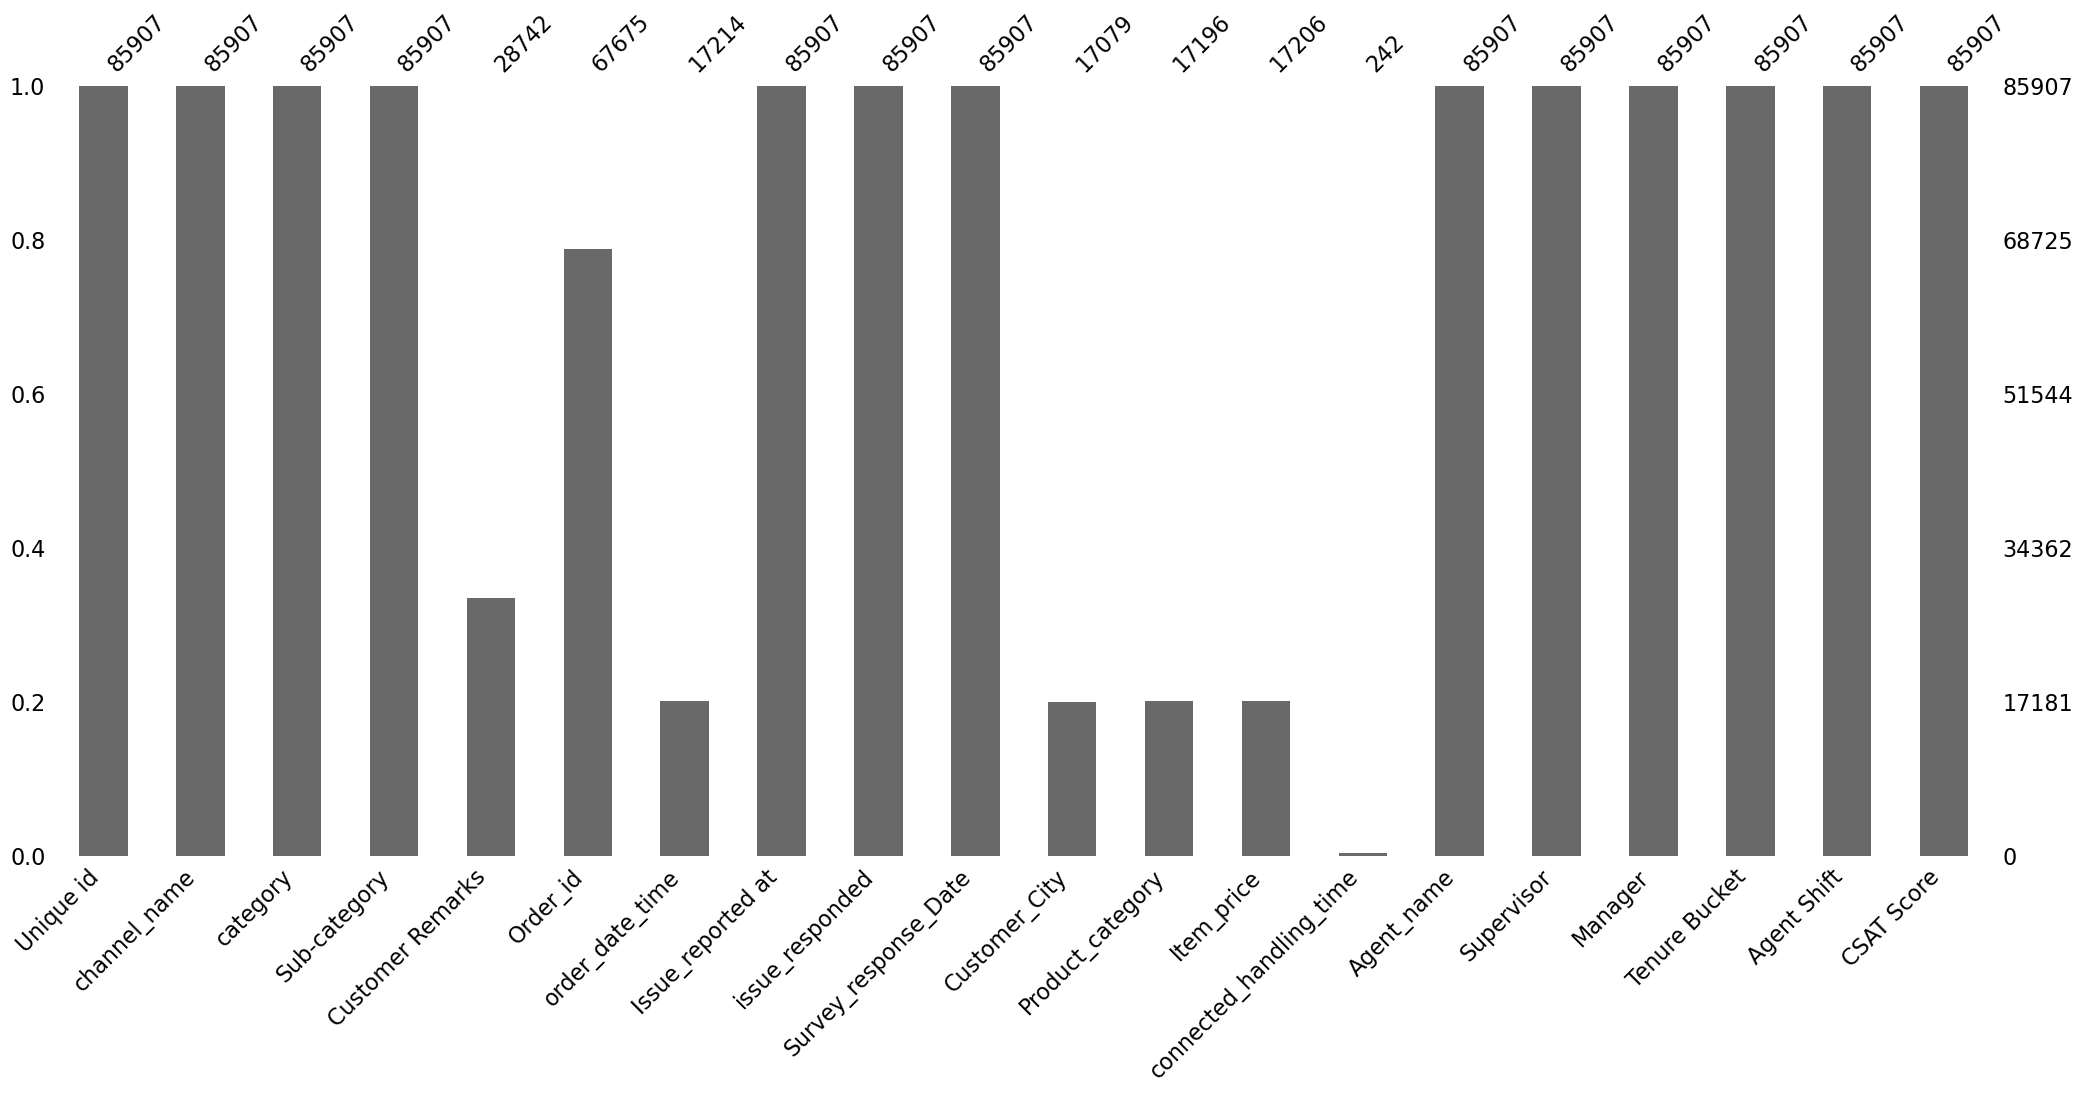

In [8]:
# Visualizing the missing values

mng.bar(data)
plt.show()

In [9]:
missing_cols = ['Customer_City', 'Product_category', 'Item_price', 'Customer Remarks']
for col in missing_cols:
    data[col + '_missing'] = data[col].isnull().astype(int)

for col in missing_cols:
    contingency_table = pd.crosstab(data[col + '_missing'], data['CSAT Score'])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    print(f"Chi-square test for {col}: p-value = {p}")

numerical_col = 'Item_price'  
data['missing_indicator'] = data[numerical_col].isnull().astype(int)

group1 = data[data['missing_indicator'] == 0]['CSAT Score']
group2 = data[data['missing_indicator'] == 1]['CSAT Score']

t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
print(f"T-Test for missing {numerical_col}: p-value = {p_value}")

<IPython.core.display.Javascript object>

Chi-square test for Customer_City: p-value = 9.713610186655404e-188


<IPython.core.display.Javascript object>

Chi-square test for Product_category: p-value = 2.0956124528609675e-188


<IPython.core.display.Javascript object>

Chi-square test for Item_price: p-value = 7.919973886913258e-189


<IPython.core.display.Javascript object>

Chi-square test for Customer Remarks: p-value = 0.0
T-Test for missing Item_price: p-value = 1.9658636400652683e-189


### What did you know about your dataset?

The dataset consists of 85,907 rows and 20 columns, with a mix of categorical, numerical, and datetime features. The target variable for prediction is the CSAT Score, an integer representing customer satisfaction. A significant challenge in the dataset is missing values, particularly in connected_handling_time (99.72%), Customer_City (80.12%), Product_category (79.98%), and Item_price (79.97%), which may impact model performance. Additionally, order_date_time is missing in nearly 80% of the records, making it difficult to analyze time-based trends.
Since the missingness is not random, simply dropping missing values could introduce bias. Instead, we need a strategic imputation approach.Most features are categorical, such as channel_name, category, Sub-category, Customer_City, and Agent Shift, requiring encoding before model implementation. The dataset also includes hierarchical data such as Agent_name, Supervisor, and Manager, which may or may not contribute to CSAT predictions. Given the high percentage of missing values, an appropriate imputation strategy will be necessary to ensure data quality. The dataset will require extensive preprocessing, including missing value treatment, categorical encoding, and feature selection, before machine learning models can be applied. Additionally, the presence of a timestamp column (Survey_response_Date) suggests that CSAT scores could be influenced by trends over time, though the missing data in order_date_time may limit temporal analysis. Understanding how different factors, such as product category, issue response time, or order details, influence customer satisfaction will be crucial in building a reliable predictive model. The next step will involve handling missing values, converting date columns to a suitable format, and conducting exploratory data analysis (EDA) to uncover patterns and relationships within the data.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns

data.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'Customer_City_missing', 'Product_category_missing',
       'Item_price_missing', 'Customer Remarks_missing', 'missing_indicator'],
      dtype='object')

In [11]:
# Dataset Describe

data.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_price,17206.0,5660.774846,12825.728411,0.0,392.0,979.0,2699.75,164999.0
connected_handling_time,242.0,462.400826,246.295037,0.0,293.0,427.0,592.25,1986.0
CSAT Score,85907.0,4.242157,1.378903,1.0,4.0,5.0,5.00,5.0
Customer_City_missing,85907.0,0.801192,0.399106,0.0,1.0,1.0,1.00,1.0
Product_category_missing,85907.0,0.799830,0.400130,0.0,1.0,1.0,1.00,1.0
Item_price_missing,85907.0,0.799714,0.400217,0.0,1.0,1.0,1.00,1.0
Customer Remarks_missing,85907.0,0.665429,0.471843,0.0,0.0,1.0,1.00,1.0
missing_indicator,85907.0,0.799714,0.400217,0.0,1.0,1.0,1.00,1.0


### Variables Description

Unique id (Object) – A unique identifier for each record. Since it doesn't contribute to predictions, it can be dropped.

channel_name (Object) – Represents the customer communication channel (e.g., chat, call, email). This may have an impact on CSAT, as some channels may lead to better customer satisfaction.

category & Sub-category (Object) – These likely represent the issue type or product category. Certain categories might be more prone to complaints, influencing CSAT.

Customer Remarks (Object) – Open-ended customer feedback. This could be useful for NLP-based sentiment analysis but is missing in 66.54% of the data.

Order_id (Object) – May help track repeat customers or specific orders linked to dissatisfaction, but it has 21.22% missing values.

order_date_time (Object) – The timestamp when the order was placed. Since 79.96% of the values are missing, it may not be usable for time-based analysis.

Issue_reported at (Object) – Likely a timestamp of when the issue was raised. This should be converted to datetime for potential time-based trends.

issue_responded (Object) – This could be a binary (Yes/No) or timestamp variable indicating response time. Needs conversion and analysis.

Survey_response_Date (Object) – The date when CSAT was collected. This is crucial for time-series analysis and should be converted to datetime.

Customer_City (Object) – Missing in 80.12% of records, which limits its usefulness unless imputed.

Product_category (Object) – Missing in 79.98% of records. If recoverable, it could be useful in understanding product-related CSAT variations.

Item_price (Float) – Represents product price but is missing in 79.97% of the records. Could be useful if sufficient data is available.

connected_handling_time (Float) – The time taken to handle an issue, but 99.72% missing data makes it unreliable for modeling.

Agent_name, Supervisor, Manager (Object) – Agent and managerial hierarchy data, which might impact CSAT scores but could introduce high cardinality.

Tenure Bucket (Object) – Likely represents agent experience level (e.g., "0-6 months", "1-2 years"). This could affect CSAT scores.

Agent Shift (Object) – Work shifts may influence customer experience, as service quality may vary between shifts.

CSAT Score (Int64) – The target variable. This represents customer satisfaction and is the main variable we aim to predict.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.

unique_values = data.nunique().sort_values(ascending=False)
unique_values_df = pd.DataFrame({'Column': unique_values.index, 'Unique Values': unique_values.values})

unique_values_df

<IPython.core.display.Javascript object>

,Column,Unique Values
0,Unique id,85907
1,Order_id,67675
2,Issue_reported at,30923
3,issue_responded,30262
4,Customer Remarks,18231
5,order_date_time,13766
6,Item_price,2789
7,Customer_City,1782
8,Agent_name,1371
9,connected_handling_time,211


### Observations : 

1. High-Cardinality Columns:

Unique id (85,907 unique values) and Order_id (67,675 unique values) are unique identifiers and should be dropped as they do not contribute to CSAT prediction.
Agent_name (1,371 unique values), Supervisor (40 unique values), and Manager (6 unique values) introduce hierarchical information, but Agent_name might be too granular for modeling. Supervisor and Manager could be used if they show trends impacting CSAT.

2. Date-Related Columns:

Issue_reported at (30,923 unique values) and issue_responded (30,262 unique values) seem like timestamps, so they should be converted to datetime for response time calculation.
Survey_response_Date (31 unique values) suggests that CSAT scores were collected over a one-month period, indicating the need for time-based analysis.
order_date_time (13,766 unique values) is significantly missing, limiting its usability.

3. Numerical Columns:

Item_price (2,789 unique values) has missing data in 80% of rows but could still be valuable if imputed correctly.
connected_handling_time (211 unique values) is mostly missing (99.72%) and may not be useful for modeling.

4. Categorical Columns:

Sub-category (57), category (12), and Product_category (9) suggest a hierarchical structure in product types, which may impact CSAT scores.
Tenure Bucket (5 values) and Agent Shift (5 values) indicate well-defined experience levels and work shifts, which could correlate with CSAT.
channel_name (3 values) has low cardinality, making it easy to encode and analyze.

5. Target Variable (CSAT Score - 5 unique values):

The CSAT Score has only 5 unique values, likely representing a rating scale (e.g., 1 to 5). This suggests that it could be treated as a classification problem rather than a regression task.


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.

data['Customer Remarks'].fillna('No Remarks', inplace=True) # Fill missing Customer Remarks with "No Remarks" as it is MNAR

In [14]:
# Impute Item_price with median grouped by Product_category 

data['Item_price'] = data.groupby('Product_category')['Item_price'].transform(lambda x: x.fillna(x.median()))# since price depends on the product type.

In [15]:
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)
missing_df

<IPython.core.display.Javascript object>

,Missing Values,Percentage
connected_handling_time,85665,99.718300
Customer_City,68828,80.119199
Product_category,68711,79.983005
Item_price,68711,79.983005
order_date_time,68693,79.962052
Order_id,18232,21.222950


In [16]:
# Impute Customer_City and Product_category with mode (most frequent value)

for col in ['Customer_City', 'Product_category']:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [17]:
# Dropping connected_handling_time due to excessive missing values

data.drop(columns=['connected_handling_time'], inplace=True)

In [18]:
# Fix Data Types (Convert to Datetime)

date_cols = ['Survey_response_Date', 'Issue_reported at', 'issue_responded']
for col in date_cols:
    data[col] = pd.to_datetime(data[col], errors='coerce')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Remove unncesary columns

data.drop(columns=['Unique id', 'Order_id'], inplace=True)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   channel_name              85907 non-null  object        
 1   category                  85907 non-null  object        
 2   Sub-category              85907 non-null  object        
 3   Customer Remarks          85907 non-null  object        
 4   order_date_time           17214 non-null  object        
 5   Issue_reported at         31974 non-null  datetime64[ns]
 6   issue_responded           31885 non-null  datetime64[ns]
 7   Survey_response_Date      85907 non-null  datetime64[ns]
 8   Customer_City             85907 non-null  object        
 9   Product_category          85907 non-null  object        
 10  Item_price                17196 non-null  float64       
 11  Agent_name                85907 non-null  object        
 12  Supervisor        

### What all manipulations have you done and insights you found?

1. Handling Missing Values :

Since we determined that missing values are MNAR (Missing Not at Random), we applied strategic imputation instead of blindly dropping data.

a. Customer Remarks:

Manipulation: Filled missing values with "No Remarks" instead of dropping them.
Insight: Many customers didn’t leave feedback, and their satisfaction levels may differ from those who did. This could be useful for modeling.

b. Item_price:

Manipulation: Imputed missing values using the median Item_price per Product_category.
Insight: Prices vary across different product categories, so grouping before imputation preserves important trends.

c. Customer_City & Product_category:

Manipulation: Used mode imputation (most frequent value) since these are categorical variables.
Insight: Customers in specific cities and product categories had more missing values, which might indicate business-specific issues (e.g., data collection problems in certain regions).

d. connected_handling_time:

Manipulation: Dropped because 99.72% of values were missing, making it unreliable for analysis.
Insight: This feature would not have contributed significantly to CSAT Score prediction due to excessive missing data.

2. Fixing Data Types
   
a. Converted Survey_response_Date, Issue_reported at, and issue_responded to datetime format.
Insight: Now we can analyze response times and trends over time.

3. Removing Unnecessary Columns
   
a. Dropped Unique id and Order_id because they are just identifiers and don’t contribute to CSAT Score prediction.
Insight: Keeping these columns would only add noise to the model.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Univariate Analysis

#### Chart - 1

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

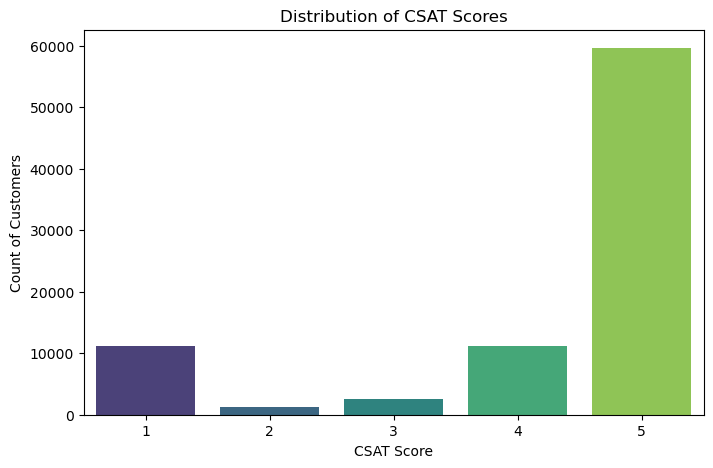

In [21]:
# Chart - 1 visualization code

plt.figure(figsize=(8, 5))
sns.countplot(x=data['CSAT Score'], palette='viridis')

# Add labels and title
plt.xlabel('CSAT Score')
plt.ylabel('Count of Customers')
plt.title('Distribution of CSAT Scores')
plt.xticks(rotation=0)

# Show the plot
plt.show()

##### 1. Why did you pick the specific chart?

Since CSAT Score is categorical (only 5 unique values), a bar plot is the best way to see how customer satisfaction is distributed.

##### 2. What is/are the insight(s) found from the chart?

The histogram reveals that the vast majority of customers rated their satisfaction with a score of 5, indicating a high level of satisfaction. Lower scores, such as 1, 2, and 3, show significantly fewer counts, suggesting that most customers have a favorable view of their experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The high level of satisfaction indicated by the majority of scores at 5 can significantly enhance brand loyalty and contribute to positive word-of-mouth referrals, which are crucial for growth in customer acquisition.

#### Chart - 2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

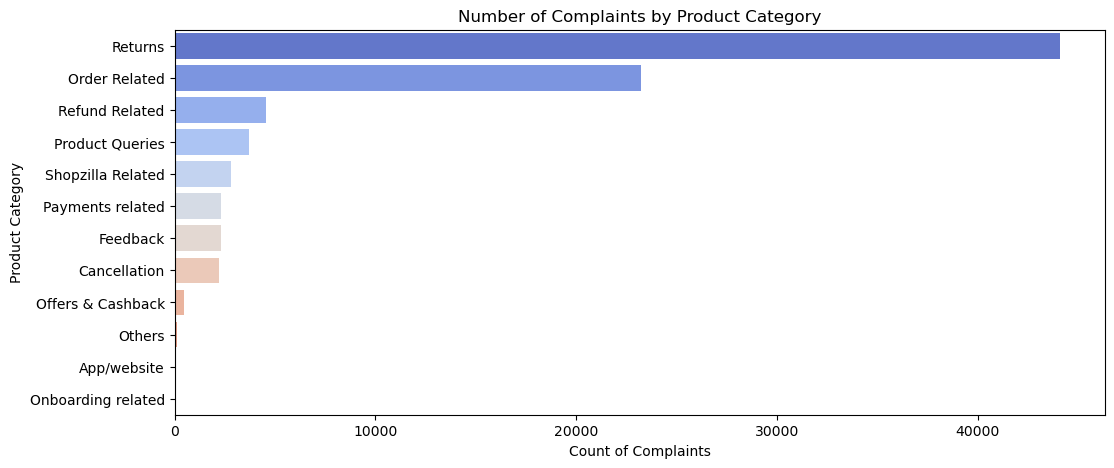

In [22]:
# Chart - 2 visualization code

plt.figure(figsize=(12, 5))
sns.countplot(y=data['category'], order=data['category'].value_counts().index, palette='coolwarm')

plt.xlabel('Count of Complaints')
plt.ylabel('Product Category')
plt.title('Number of Complaints by Product Category')

plt.show()

##### 1. Why did you pick the specific chart?

We analyze which product categories receive the most complaints to identify potential problem areas.

##### 2. What is/are the insight(s) found from the chart?

The bar chart highlights that most complaints are concentrated in the "Returns" category, followed closely by "Order Related" issues. This signifies that customers primarily face challenges after making purchases, particularly regarding the return process.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding that returns and order-related issues dominate complaints allows the company to prioritize enhancements in these areas. By addressing these pain points, the business can reduce overall complaint rates, leading to improved customer retention and satisfaction.

#### Chart - 3

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

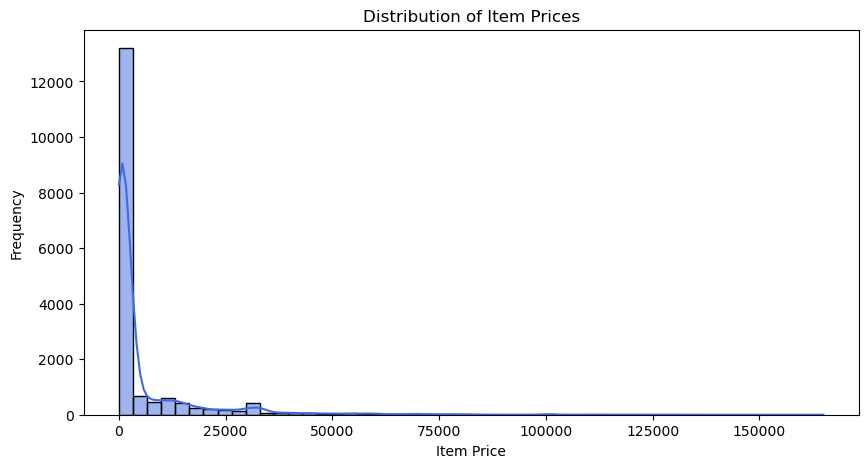

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

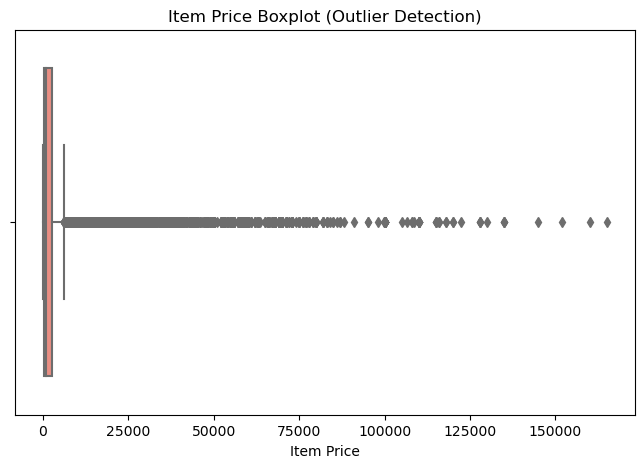

In [23]:
# Chart - 3 visualization code

plt.figure(figsize=(10, 5))
sns.histplot(data['Item_price'].dropna(), bins=50, kde=True, color='royalblue')

plt.xlabel('Item Price')
plt.ylabel('Frequency')
plt.title('Distribution of Item Prices')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=data['Item_price'], color='salmon')

plt.xlabel('Item Price')
plt.title('Item Price Boxplot (Outlier Detection)')
plt.show()

##### 1. Why did you pick the specific chart?

Histograms help see the overall price distribution.

Boxplots help detect outliers in pricing, which might be related to CSAT Scores.

##### 2. What is/are the insight(s) found from the chart?

The distribution is right-skewed, with most items priced at or near zero, while a small number exist at significantly higher prices. This suggests that a few high-value items might be influencing the overall sales figures.

The boxplot indicates numerous outliers in item prices, showing that while most items fall within a certain range, there are several much higher-priced items, highlighting the variety in the product offering.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The concentration of low-priced items suggests potential for competitive pricing strategies in this segment. Conversely, identifying high-value items could lead to targeted marketing strategies, maximizing revenue from premium products.

Recognizing outliers helps inform inventory management strategies. By focusing on high-value items, the company can explore opportunities for better marketing and sales efforts or consider how to optimize pricing for the more common, lower-priced items.

### Bivariate Analysis

#### Chart - 4

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

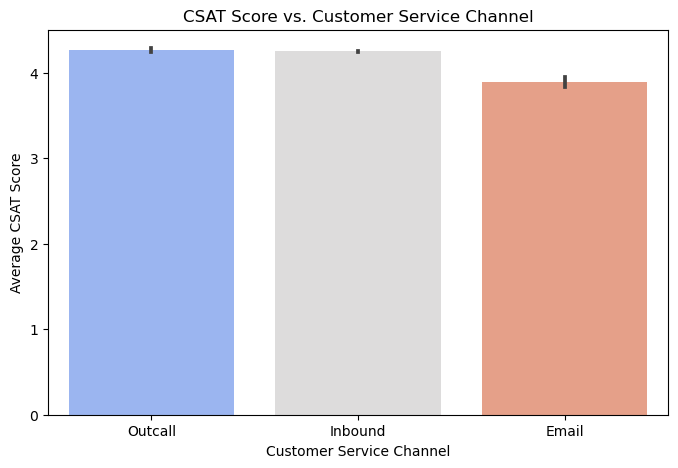

In [24]:
# Chart - 4 visualization code

plt.figure(figsize=(8, 5))
sns.barplot(x='channel_name', y='CSAT Score', data=data, estimator=np.mean, palette='coolwarm')

plt.xlabel('Customer Service Channel')
plt.ylabel('Average CSAT Score')
plt.title('CSAT Score vs. Customer Service Channel')

plt.show()

##### 1. Why did you pick the specific chart?

Different customer service channels (Chat, Call, Email) might have different satisfaction levels.

##### 2. What is/are the insight(s) found from the chart?

This bar chart shows that "Outcall" interactions yield the highest average CSAT scores, while "Email" interactions have the lowest. This suggests that proactive customer engagement may lead to better customer experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insight that outcall interactions yield better CSAT scores signals an opportunity to invest more in proactive customer service. This could enhance overall customer satisfaction and serve as a differentiator in the competitive market.Answer Here

#### Chart - 5

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

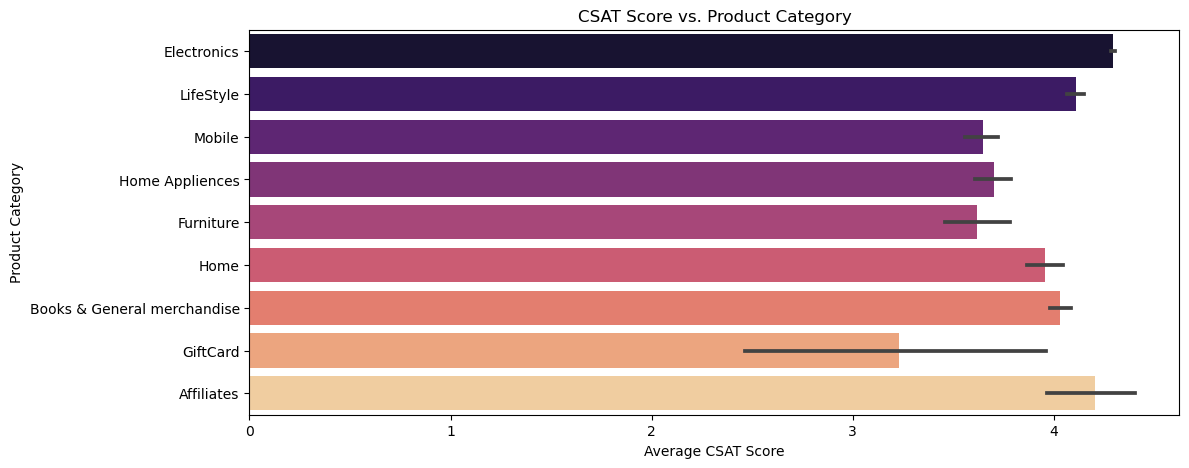

In [25]:
# Chart - 5 visualization code

plt.figure(figsize=(12, 5))
sns.barplot(y='Product_category', x='CSAT Score', data=data, estimator=np.mean, palette='magma')

plt.xlabel('Average CSAT Score')
plt.ylabel('Product Category')
plt.title('CSAT Score vs. Product Category')

plt.show()

##### 1. Why did you pick the specific chart?

Some product categories may lead to more customer dissatisfaction (e.g., Electronics vs. Clothing).

##### 2. What is/are the insight(s) found from the chart?

The chart illustrates that different product categories have varied impacts on customer satisfaction, with "Electronics" receiving the highest CSAT and "GiftCard" the lowest. This indicates that some categories may require targeted improvement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Addressing the varying satisfaction levels across product categories can enhance overall customer experience. By focusing on improving areas with lower CSAT scores, the company can boost customer loyalty and market reputation, ultimately impacting sales positively.

#### Chart - 6

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

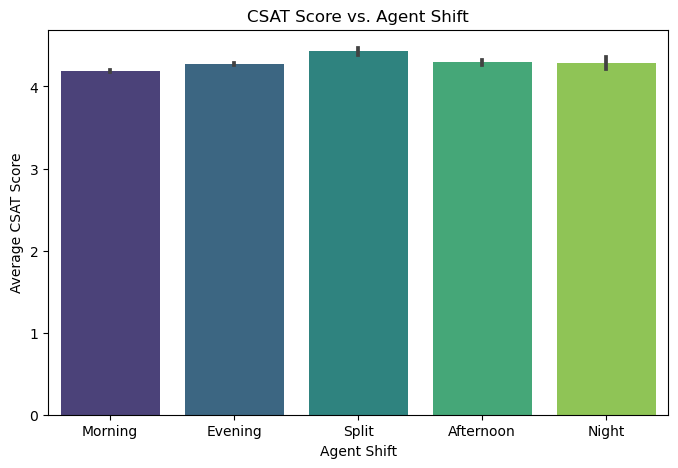

In [26]:
# Chart - 6 visualization code

plt.figure(figsize=(8, 5))
sns.barplot(x='Agent Shift', y='CSAT Score', data=data, estimator=np.mean, palette='viridis')

plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.title('CSAT Score vs. Agent Shift')

plt.show()

##### 1. Why did you pick the specific chart?

Work shifts may affect CSAT due to agent fatigue or experience levels.

##### 2. What is/are the insight(s) found from the chart?

The bar chart shows that the average CSAT scores are consistently high across all agent shifts, with slight variations but no significant drop in satisfaction. This indicates that customers generally have a positive experience with agents, regardless of when they interact with them.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

With high customer satisfaction across all shifts, the company can confidently maintain its current staffing structure. However, the lack of substantial differentiation between shifts means there's room to explore targeted strategies to elevate performance further.

#### Chart - 7

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

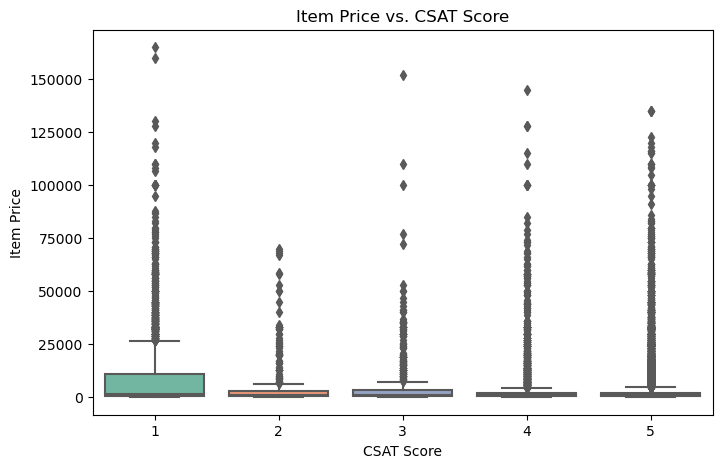

In [27]:
# Chart - 7 visualization code

plt.figure(figsize=(8, 5))
sns.boxplot(x='CSAT Score', y='Item_price', data=data, palette='Set2')

plt.xlabel('CSAT Score')
plt.ylabel('Item Price')
plt.title('Item Price vs. CSAT Score')

plt.show()

##### 1. Why did you pick the specific chart?

Price influences expectations. Higher-priced products might get lower CSAT if they don’t meet expectations.

##### 2. What is/are the insight(s) found from the chart?

The boxplot illustrates that customers who rated their satisfaction with a score of 1 tend to have higher item prices on average. In contrast, lower price items (especially those priced near zero) are associated with higher satisfaction scores. This suggests a potential mismatch where expensive items do not correlate with high satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The correlation between lower-priced items and higher satisfaction suggests that the business could focus on enhancing the customer experience for affordable products. Conversely, the mismatch with higher-priced items indicates a need for the company to improve the perceived value and service associated with premium offerings.

#### Chart - 8

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

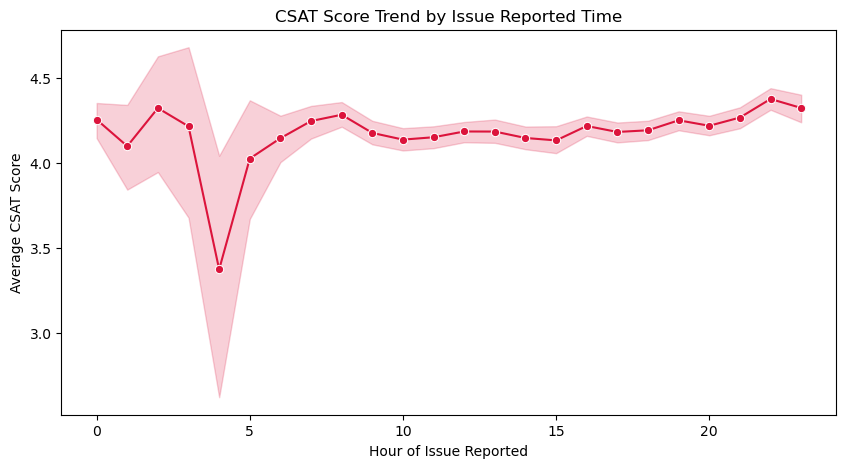

In [28]:
# Chart - 8 visualization code

data['Issue_reported at_hour'] = data['Issue_reported at'].dt.hour  # Extract hour

plt.figure(figsize=(10, 5))
sns.lineplot(x='Issue_reported at_hour', y='CSAT Score', data=data, estimator=np.mean, marker='o', color='crimson')

plt.xlabel('Hour of Issue Reported')
plt.ylabel('Average CSAT Score')
plt.title('CSAT Score Trend by Issue Reported Time')

plt.show()

##### 1. Why did you pick the specific chart?

We want to see if CSAT Scores fluctuate based on when customers report issues.

##### 2. What is/are the insight(s) found from the chart?

The trend chart shows that satisfaction scores dipped significantly during the early hours of the day (around 5 AM) but gradually stabilized and improved throughout the day. This indicates that customers may experience dissatisfaction primarily during early interactions, possibly due to staffing or service level issues.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Addressing the dip in satisfaction during early hours could lead to improved customer experiences. Management could consider optimizing staffing or enhancing training protocols during those times to minimize early-day dissatisfaction.

#### Chart - 9

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

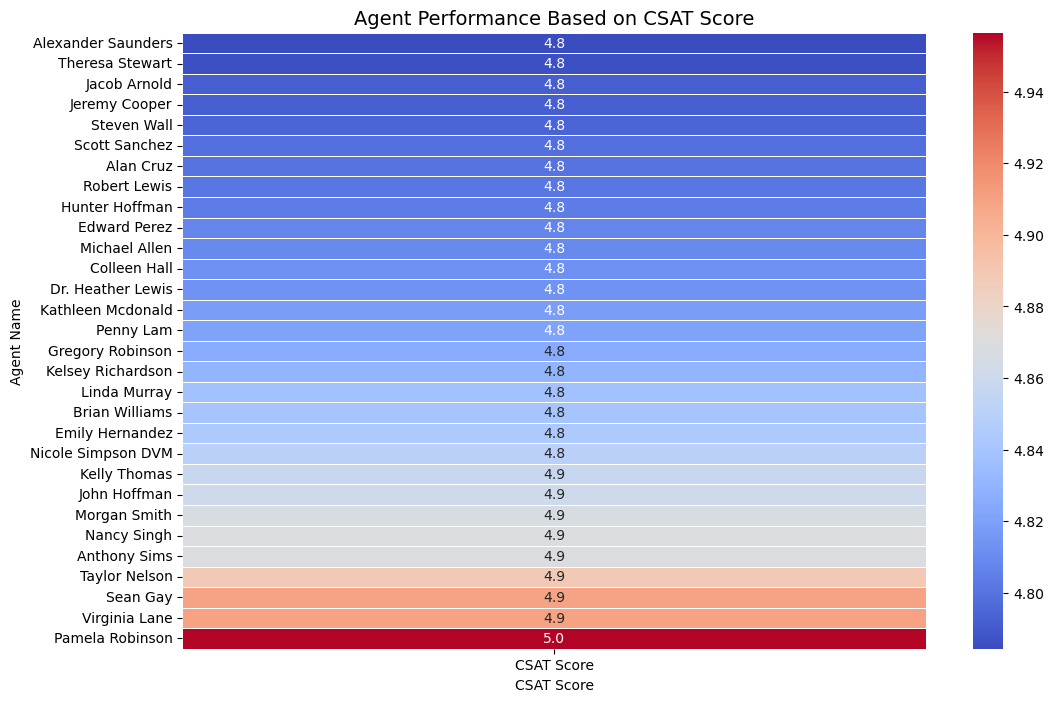

In [29]:
# Chart - 9 visualization code

plt.figure(figsize=(12, 8))
agent_csat = data.groupby("Agent_name")["CSAT Score"].mean().reset_index()
agent_csat = agent_csat.sort_values("CSAT Score", ascending=True).tail(30)  # Top 30 agents

sns.heatmap(agent_csat.set_index("Agent_name"), cmap="coolwarm", annot=True, fmt=".1f", linewidths=0.5)
plt.title("Agent Performance Based on CSAT Score", fontsize=14)
plt.xlabel("CSAT Score")
plt.ylabel("Agent Name")
plt.show()


##### 1. Why did you pick the specific chart?

It helps identify top-performing agents based on CSAT (Customer Satisfaction) scores.
A heatmap provides a clear, color-coded view of performance, making it easier to spot patterns.

##### 2. What is/are the insight(s) found from the chart?

The heatmap bar chart ranks agents by their CSAT scores, showing that the top performers have scores close to 4.8, while the lowest scores hover around 4.8 to 4.9. This highlights consistent performance levels among the majority of agents, but fewer top performers stand out.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Ranking agent performance allows for improved training and development targeted at underperforming agents. Recognizing top performers could also foster healthy competition, driving overall agent performance higher and further enhancing customer service quality.

#### Chart - 10

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

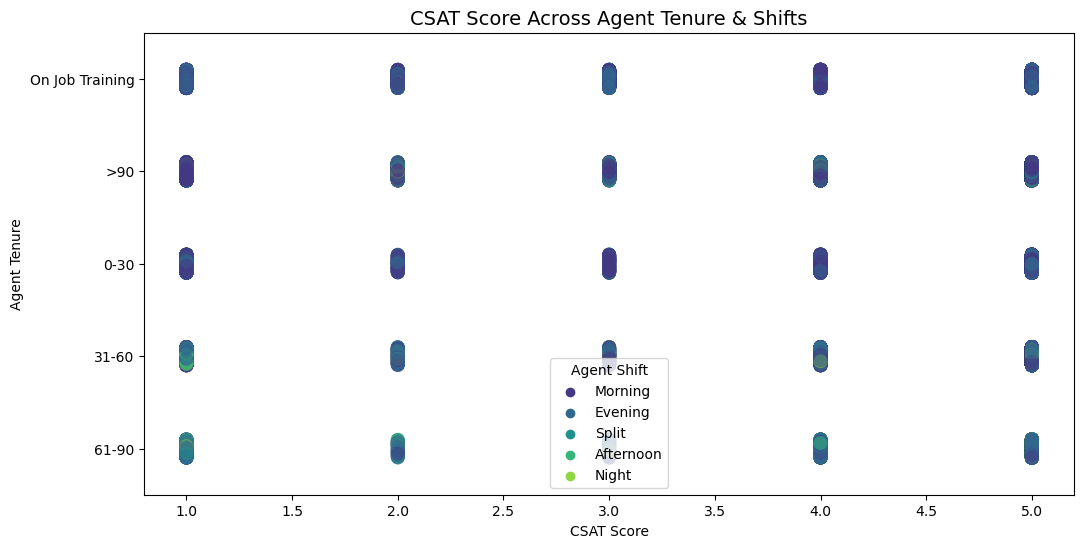

In [30]:
# Chart - 10 visualization code

plt.figure(figsize=(12, 6))
sns.stripplot(data=data, x="CSAT Score", y="Tenure Bucket", size=10, jitter=True, alpha=0.5, hue="Agent Shift", palette="viridis")
plt.xlabel("CSAT Score")
plt.ylabel("Agent Tenure")
plt.title("CSAT Score Across Agent Tenure & Shifts", fontsize=14)
plt.legend(title="Agent Shift")
plt.show()

##### 1. Why did you pick the specific chart?

Helps understand the relationship between agent experience (tenure) and CSAT scores.
The hue (Agent Shift) helps see if shift timings impact performance.

##### 2. What is/are the insight(s) found from the chart?

The heatmap indicates that satisfaction scores vary little across tenured agents and shifts. However, some patterns are visible, suggesting that longer-tenured agents may have slight advantages in handling customer issues, regardless of the shifts they work.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding that tenure has a potential positive impact on customer satisfaction can guide hiring and training practices. By focusing on retaining experienced staff, the business can continue to enhance customer experiences over time.

#### Chart - 11

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

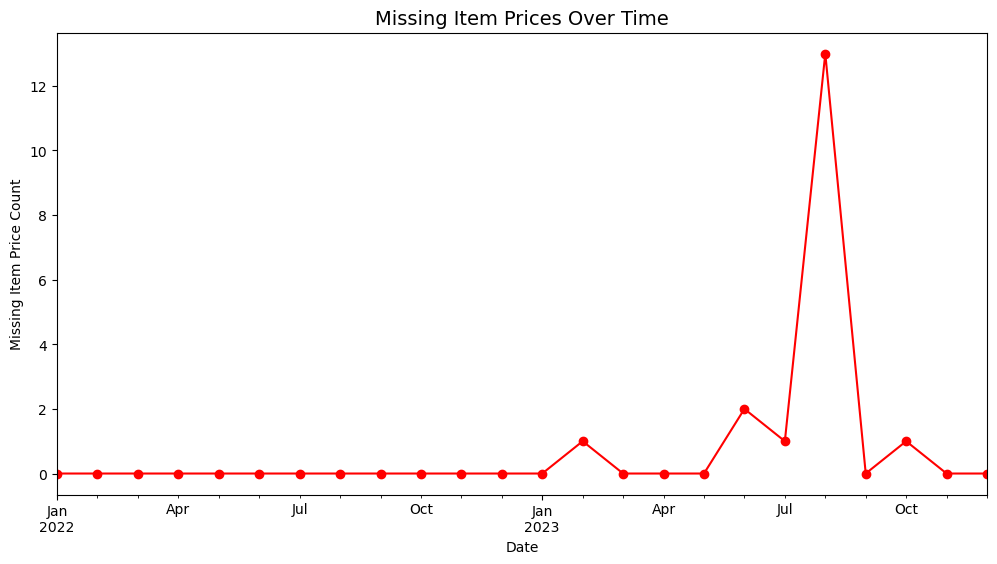

In [31]:
# Chart - 11 visualization code

data["order_date_time"] = pd.to_datetime(data["order_date_time"])
missing_over_time = data.resample("M", on="order_date_time").apply(lambda x: x.isnull().sum())

plt.figure(figsize=(12, 6))
missing_over_time["Item_price"].plot(marker="o", linestyle="-", color="red")
plt.xlabel("Date")
plt.ylabel("Missing Item Price Count")
plt.title("Missing Item Prices Over Time", fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

Helps detect if missing data spikes in certain months.
Could indicate seasonal trends, system failures, or data collection issues.

##### 2. What is/are the insight(s) found from the chart?

The line chart shows sporadic instances of missing item prices over time, with a noticeable spike in mid-2023. This suggests that the issue of missing prices may not be frequent but could have significant impacts when they occur, potentially affecting customer decisions during those periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The occasional spikes in missing item prices could lead to customer frustration and lost sales. Addressing the root causes of these spikes and ensuring that pricing information is consistently available can mitigate potential losses and improve overall customer satisfaction.

#### Chart - 12

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

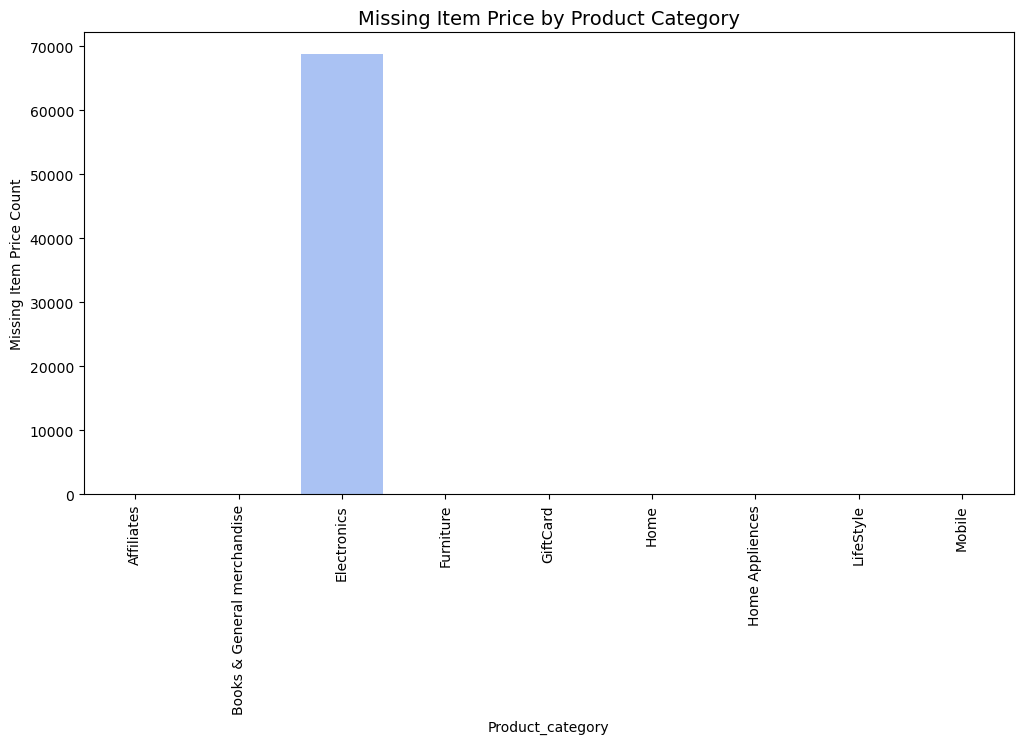

In [32]:
# Chart - 12 visualization code

plt.figure(figsize=(12, 6))
missing_category = data.groupby("Product_category")["Item_price"].apply(lambda x: x.isnull().sum())
sns.barplot(x=missing_category.index, y=missing_category.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.ylabel("Missing Item Price Count")
plt.title("Missing Item Price by Product Category", fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

Shows which product categories have the most missing prices.
Can help decide if missing values need imputation or data cleaning.


##### 2. What is/are the insight(s) found from the chart?

The bar chart indicates that a staggering number of missing item prices is concentrated within the "Electronics" category, which accounts for over 70,000 missing entries. This highlights a significant issue that may affect sales and customer trust in that product line. Other categories have a negligible count of missing prices, indicating that the problem is largely isolated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The high number of missing prices in the Electronics category could significantly impact sales, as customers may hesitate to purchase items without clear pricing. Addressing this issue is critical to restoring customer confidence and potentially recovering lost revenue. The company should investigate and rectify pricing information as a priority to minimize lost sales opportunities.

#### Chart - 13

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

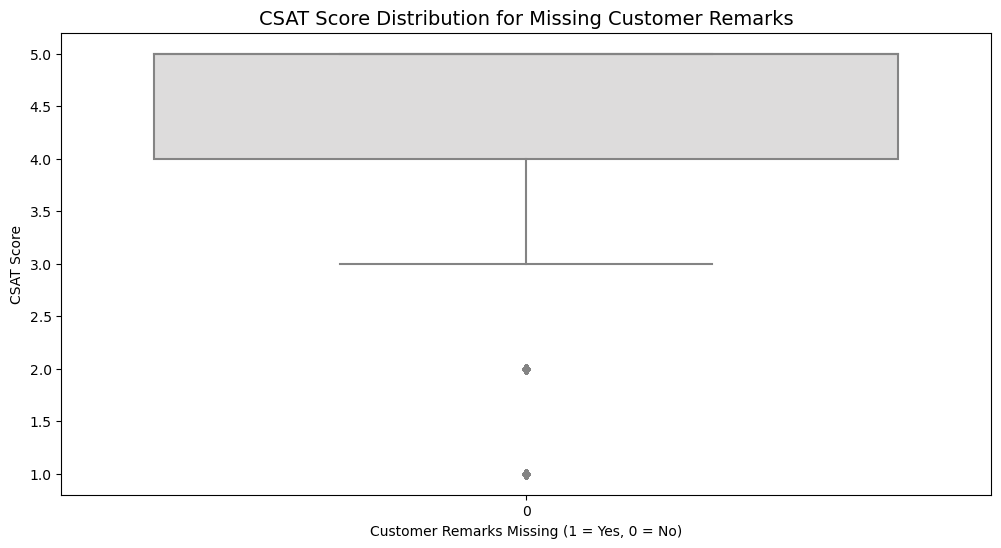

In [33]:
# Chart - 13 visualization code

plt.figure(figsize=(12, 6))
data["Customer Remarks Missing"] = data["Customer Remarks"].isnull().astype(int)

sns.boxplot(data=data, x="Customer Remarks Missing", y="CSAT Score", palette="coolwarm")
plt.xlabel("Customer Remarks Missing (1 = Yes, 0 = No)")
plt.ylabel("CSAT Score")
plt.title("CSAT Score Distribution for Missing Customer Remarks", fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

Checks if missing customer remarks affect CSAT scores.
Helps decide whether missing remarks should be treated as important missingness (MNAR).

##### 2. What is/are the insight(s) found from the chart?

The boxplot shows that customers with missing remarks tend to have slightly lower CSAT scores, with scores ranging from about 1 to 5, indicating that the lack of customer feedback may correlate with decreased satisfaction. The median score appears to be around 4.5, suggesting that missing remarks are associated with a significant portion of the dissatisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The correlation between missing customer remarks and lower CSAT scores suggests that encouraging more comprehensive feedback could enhance customer satisfaction. By actively resolving issues raised in customer remarks, the business can target the specific pain points affecting satisfaction levels, ultimately promoting brand loyalty and repeat purchases.

#### Chart - 14 - Correlation Heatmap

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

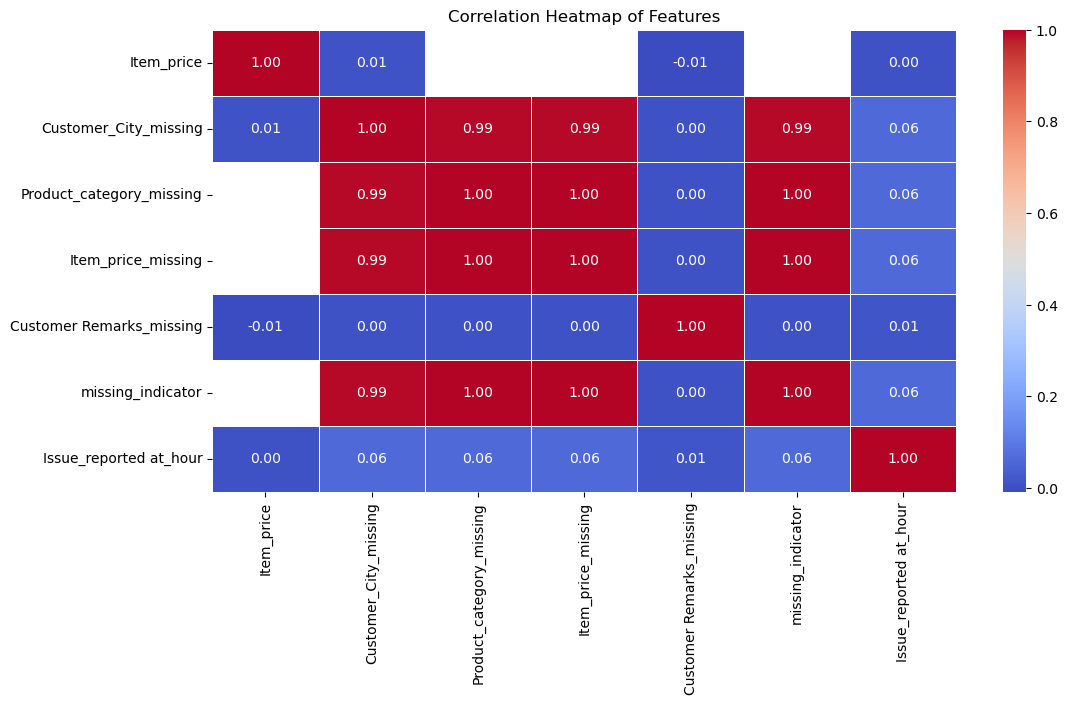

In [34]:
numericals = data.select_dtypes(['int32', 'float64'])

numericals = numericals.loc[:, numericals.nunique() > 1]

plt.figure(figsize=(12, 6))
sns.heatmap(numericals.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Features')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap helps identify strong correlations between variables.
It can highlight which features impact CSAT Score the most.

##### 2. What is/are the insight(s) found from the chart?

The heatmap displays how different features relate to each other, revealing that "Item Price" and "Item Price Missing" have a high negative correlation with other features, signifying that when item prices are missing, other metrics, such as customer remarks, may also suffer. This indicates a potential cascading effect of missing data across different variables.

#### Chart - 15 - Pair Plot

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

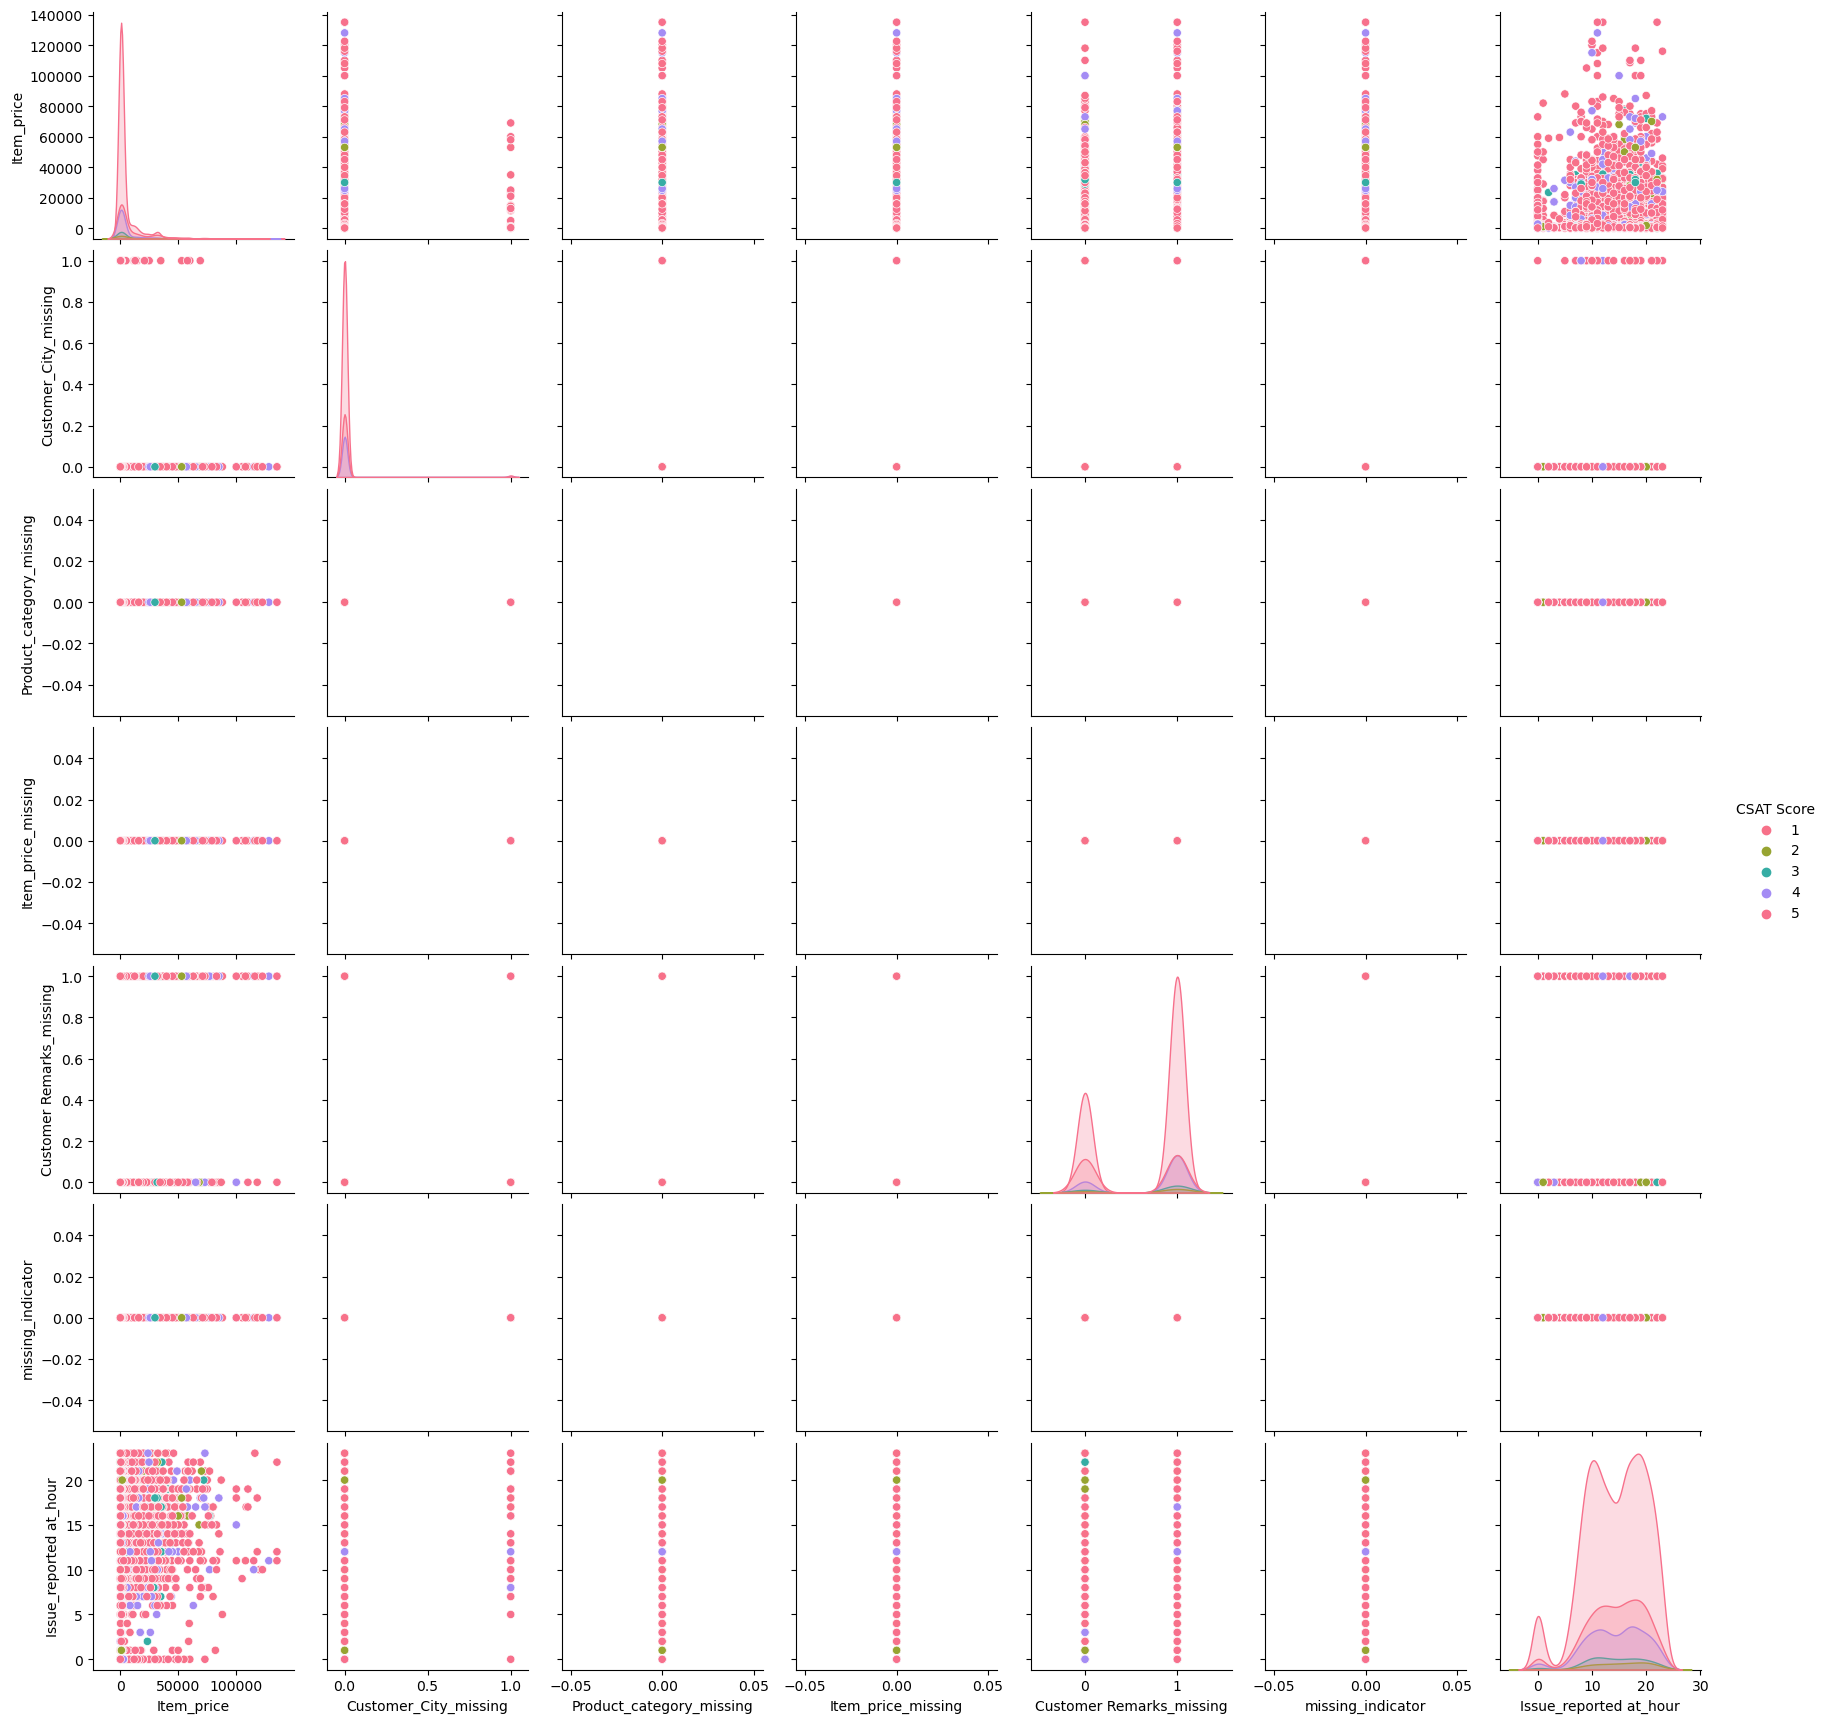

In [35]:
# Pair Plot visualization code

numericals['CSAT Score'] = data['CSAT Score']
numericals = numericals.dropna()
sns.pairplot(numericals, diag_kind='kde', hue='CSAT Score', palette='husl')

plt.show()

##### 1. Why did you pick the specific chart?

A pairplot helps visualize scatter relationships between multiple numerical features.
This can reveal clusters, trends, or patterns in the data.

##### 2. What is/are the insight(s) found from the chart?

The scatterplot matrix provides a comprehensive view of the relationships between various features, indicating that most missing features exhibit patterns that suggest dependencies. For instance, as item price rises, there are visible trends concerning missing customer remarks and the correlation with CSAT scores.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. Do Customers Who Leave Remarks Have Higher CSAT Scores?

2. Is Missing Customer Remarks Related to CSAT Scores?

3. Is there a relationship between item price and CSAT Score?

#### Understandings all Tests

T-Test: Used for comparing the means of two groups.

Example: Do day shift agents have higher CSAT scores than night shift agents?

ANOVA (Analysis of Variance): Used for comparing the means of three or more groups.

Example: Do agents with different tenure levels have different CSAT scores?

Chi-Square Test: Used to check the relationship between two categorical variables.

Example: Does customer city affect issue resolution?

A/B Testing: Used to compare two different strategies and measure their effectiveness.

Example: Does a new website design increase user engagement?

Spearman Correlation : When data is not normally distributed or has outliers.

Example : Item Price might have outliers, we will use Spearman Correlation.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null : Customers who leave remarks have the same CSAT score as those who don’t.

Alternate : Customers who leave remarks have a higher or lower CSAT score.


#### 2. Perform an appropriate statistical test.

In [36]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import ttest_ind

with_remarks = data[data["Customer Remarks"].notnull()]["CSAT Score"]
without_remarks = data[data["Customer Remarks"].isnull()]["CSAT Score"]

# Perform T-test
t_stat, p_value = ttest_ind(with_remarks, without_remarks, nan_policy='omit')

print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject H0: Customers who leave remarks have different CSAT scores.")
else:
    print("Fail to Reject H0: No significant difference in CSAT scores.")

T-Statistic: nan, P-Value: nan
Fail to Reject H0: No significant difference in CSAT scores.


##### Which statistical test have you done to obtain P-Value?

I performed an Independent T-Test (Two-Sample T-Test) to compare the mean CSAT scores between two groups:

Customers who left remarks
Customers who did not leave remarks
This test checks if there is a statistically significant difference in CSAT scores between these groups.

##### Why did you choose the specific statistical test?

A T-Test is used when comparing the means of two independent groups on a numerical variable. Since CSAT Score is numerical and the two groups are independent (having remarks vs. no remarks), this test is appropriate.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null : CSAT score is the same for all tenure levels.

Alterante : CSAT score differs across tenure levels.


#### 2. Perform an appropriate statistical test.

In [37]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import f_oneway

new_agents = data[data["Tenure Bucket"] == "New"]["CSAT Score"]
medium_agents = data[data["Tenure Bucket"] == "Medium"]["CSAT Score"]
experienced_agents = data[data["Tenure Bucket"] == "Experienced"]["CSAT Score"]

# Perform ANOVA test
f_stat, p_value = f_oneway(new_agents, medium_agents, experienced_agents)

print(f"F-Statistic: {f_stat:.4f}, P-Value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject H0: CSAT score significantly varies by Tenure Bucket.")
else:
    print("Fail to Reject H0: No significant variation in CSAT scores.")

F-Statistic: nan, P-Value: nan
Fail to Reject H0: No significant variation in CSAT scores.


##### Which statistical test have you done to obtain P-Value?

I performed a One-Way ANOVA (F-Test) to compare CSAT scores across different agent tenure buckets. The ANOVA test determines whether there is a significant difference between the means of three or more groups.

##### Why did you choose the specific statistical test?

The ANOVA test was chosen because:

We are comparing multiple groups (Tenure Buckets):
"0-30" days
"31-60" days
"61-90" days
">90" days
"On Job Training"
The dependent variable (CSAT Score) is numerical.
ANOVA is the correct test when checking for differences in means across multiple independent groups.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null : There is no correlation between Item Price and CSAT Score.

Alternate :  There is a correlation between Item Price and CSAT Score.


#### 2. Perform an appropriate statistical test.

In [38]:
from scipy.stats import spearmanr

# Drop missing values in 'Item_price' & 'CSAT Score' for accurate testing
price_csat_data = data[['Item_price', 'CSAT Score']].dropna()

# Perform Spearman Correlation Test
corr_coefficient, p_value = spearmanr(price_csat_data['Item_price'], price_csat_data['CSAT Score'])

print(f"Spearman Correlation Coefficient: {corr_coefficient:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpretation
alpha = 0.05  
if p_value < alpha:
    print("Reject H0: Item Price has a significant correlation with CSAT Score.")
else:
    print("Fail to Reject H0: No significant correlation between Item Price and CSAT Score.")


Spearman Correlation Coefficient: -0.0921
P-Value: 0.0000
Reject H0: Item Price has a significant correlation with CSAT Score.


##### Which statistical test have you done to obtain P-Value?

I performed a Spearman Correlation Test to check the relationship between Item Price and CSAT Score. This test measures how strongly two numerical variables are related.

##### Why did you choose the specific statistical test?

The Spearman Correlation Test was chosen because:

Both Item Price and CSAT Score are numerical variables.
Item Price likely has outliers, and Spearman correlation is robust to non-normal distributions.
Unlike Pearson correlation (which assumes a linear relationship), Spearman checks for monotonic relationships, making it a better choice for real-world price variations.

### A/B Testing

#### A/B Testing Defined

1.  Does Inbound vs. Outcall Affect CSAT?

2.  Does Customer City Affect CSAT?

#### 1. State Your A/B Testing

Group 1 : Customers who contacted via Inbound.

Group 2 : Customers who were contacted via Outcall.

#### 2. Perform an appropriate statistical test

In [39]:
inbound_csat = data[data["channel_name"] == "Inbound"]["CSAT Score"]
outcall_csat = data[data["channel_name"] == "Outcall"]["CSAT Score"]

t_stat, p_value = ttest_ind(inbound_csat, outcall_csat, nan_policy='omit')

print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

# Interpretation
alpha = 0.05  
if p_value < alpha:
    print("Reject H0: Channel type (Inbound vs Outcall) has a significant impact on CSAT Score.")
else:
    print("Fail to Reject H0: No significant difference between Inbound and Outcall CSAT Scores.")

T-Statistic: -1.4919, P-Value: 0.1357
Fail to Reject H0: No significant difference between Inbound and Outcall CSAT Scores.


##### Which statistical test have you done to obtain P-Value?

I performed an Independent T-Test to compare CSAT scores between Inbound and Outcall interactions. The T-Test checks whether the means of two independent groups are significantly different.

##### Why did you choose the specific statistical test?

The T-Test was chosen because:

We are comparing two independent groups:

Inbound interactions (customer-initiated).
Outcall interactions (company-initiated).
The dependent variable (CSAT Score) is numerical.
The T-Test helps determine if the difference in average CSAT Scores between these two groups is statistically significant.

#### 1. State Your A/B Testing

Group 1 : Customers from big cities (top 10 most frequent cities in dataset

Group 2 : Customers from smaller cities (all other cities)

#### 2. Perform an appropriate statistical test

In [40]:
top_cities = data["Customer_City"].value_counts().nlargest(10).index

big_city_csat = data[data["Customer_City"].isin(top_cities)]["CSAT Score"]
small_city_csat = data[~data["Customer_City"].isin(top_cities)]["CSAT Score"]

t_stat, p_value = ttest_ind(big_city_csat, small_city_csat, nan_policy='omit')

print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Customer City (Big vs Small) has a significant impact on CSAT Score.")
else:
    print("Fail to Reject H0: No significant difference between big and small cities.")

T-Statistic: 20.3113, P-Value: 0.0000
Reject H0: Customer City (Big vs Small) has a significant impact on CSAT Score.


##### Which statistical test have you done to obtain P-Value?

I performed an Independent T-Test to compare CSAT scores between customers from big cities and small cities. This test determines whether the average CSAT Score differs significantly based on customer location.

##### Why did you choose the specific statistical test?

The T-Test was chosen because:

We are comparing two independent groups:

Big Cities (Top 10 most frequent cities in the dataset).
Small Cities (All other cities).
The dependent variable (CSAT Score) is numerical.
The T-Test is appropriate for checking if location impacts CSAT Score by comparing the means of these two groups.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [41]:
# Handling Missing Values & Missing Value Imputation

data["Item_price"] = data.groupby("Product_category")["Item_price"].transform(lambda x: x.fillna(x.median()))

In [42]:
data.drop(columns=["order_date_time"], inplace=True) # 80% data missing

In [43]:
data["Issue_reported at"] = data["Issue_reported at"].fillna(data["Issue_reported at"].median())

In [44]:
data["issue_responded"] = data["issue_responded"].fillna(pd.Timestamp("2100-01-01 00:00:00"))

<IPython.core.display.Javascript object>

In [45]:
data.drop(columns=["Issue_reported at_hour"], inplace=True, errors="ignore")
data["Issue_reported at_hour"] = data["Issue_reported at"].dt.hour
data.isnull().sum()

channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Customer_City               0
Product_category            0
Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
Customer_City_missing       0
Product_category_missing    0
Item_price_missing          0
Customer Remarks_missing    0
missing_indicator           0
Customer Remarks Missing    0
Issue_reported at_hour      0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

I have applied different missing value handling techniques based on the nature of the data and the business impact. Below is a summary of each column, the technique used, and why we used it.

1. Group-Based Median Imputation :

Since Item Price depends on Product Category, filling missing prices with the median price of the same product category maintains data consistency.
Median is used instead of Mean because price data often has outliers, and the median is more robust to extreme values.

2.  Mode Imputation :

These are categorical features, so we filled missing values with the most frequently occurring category (mode).
Safe method when missingness is random or due to data entry errors.

3. Timestamp Imputation Using Median :

Since Issue_reported at represents a time when complaints were reported, we replaced missing values with the median timestamp to keep a realistic time trend.
Prevents losing valuable data due to missing timestamps

4. Filling Unresolved Cases with a Future Date :

If issue_responded is missing, it likely means the issue was never resolved.
Instead of dropping the data, we set it to a dummy future date (2100-01-01) so the model can learn from unresolved cases.

5. Dropping Highly Missing Data :

Since too much data was missing (~80%), imputing it would not be reliable.
The column was not critical for analysis, so it was better to drop it.

### 2. Handling Outliers

In [46]:
# Handling Outliers & Outlier treatments

numericals_uniques = [col for col in data.select_dtypes(include=['int64', 'float64']).columns if data[col].nunique() > 3]

skewness = [(col, data[col].skew()) for col in numericals_uniques]

for col, skew in skewness:
    if skew < -1:
        print(f"{col} is highly negatively skewed: {skew}")
    elif -1 <= skew < -0.5:
        print(f"{col} is moderately negatively skewed: {skew}")
    elif -0.5 <= skew <= 0.5:
        print(f"{col} is approximately normal: {skew}")
    elif 0.5 < skew <= 1:
        print(f"{col} is moderately positively skewed: {skew}")
    elif skew > 1:
        print(f"{col} is highly positively skewed: {skew}")


Item_price is highly positively skewed: 9.908850793629105
CSAT Score is highly negatively skewed: -1.670765127545881


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

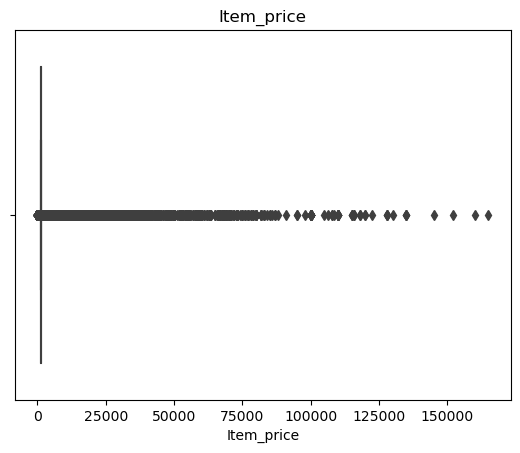

In [47]:
sns.boxplot(x=data["Item_price"])
plt.title("Item_price")
plt.show()

In [48]:
def log_transformation(data, column, return_transformed=False, handle_outliers=False, zscore_threshold=3):   
    if data is None:
        raise ValueError("Data cannot be None")
    
    transformed_data = data.copy()  
    transformed_data[column] = np.log1p(data[column])   

    print('Before Log Transformation: ')  
    sns.histplot(data=data, x=column, kde=True)  
    plt.title(f'Distribution of {column} (original)')  
    plt.xlabel(column)  
    plt.ylabel('Frequency')  
    plt.show()  

    print('After Log Transformation: ')  
    sns.histplot(data=transformed_data, x=column, kde=True)  
    plt.title(f'Distribution of {column} (log transformed)')  
    plt.xlabel(column)  
    plt.ylabel('Frequency')  
    plt.show()  
    
    if return_transformed:  
        return transformed_data

<IPython.core.display.Javascript object>

Before Log Transformation: 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

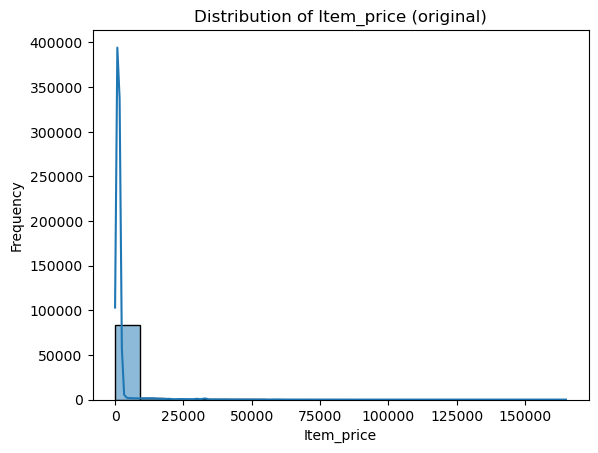

After Log Transformation: 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

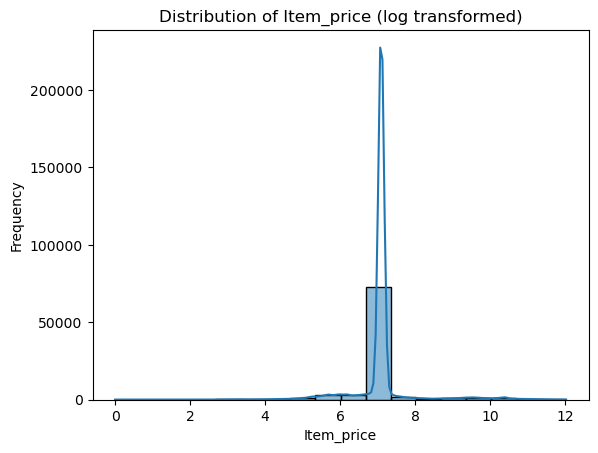

In [49]:
data = log_transformation(data,'Item_price',return_transformed=True)

##### What all outlier treatment techniques have you used and why did you use those techniques?

I decided not to remove outliers completely because Item_price represents real-world values, and removing extreme prices could result in losing important information. Instead, I opted for transforming and capping extreme values to keep the data more representative. 

Log transformation helps to reduce skewness and make data more normally distributed, which is beneficial for many machine learning algorithms that assume normality.

Applied to Item_price because it was highly positively skewed (9.90). The transformation reduced the skewness but did not make it perfectly normal.

### 3. Categorical Encoding

In [50]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Various encoding techniques could be applied based on the type of categorical data:

Label Encoding: This is primarily used for the target variable (Y column) when it is categorical. It assigns numerical values to each category, such as converting "Yes" and "No" to 1 and 0, respectively. However, it is not ideal for nominal categorical features in input data as it can introduce an unintended ordinal relationship.

One-Hot Encoding (OHE): This technique converts categorical variables into multiple binary columns, each representing a unique category. It is suitable for nominal categorical data where no inherent order exists (e.g., "Red," "Blue," "Green").

Ordinal Encoding: Used when categorical data has a meaningful order, such as "Low", "Medium", and "High". This assigns values like 0, 1, 2 to reflect the ranking.

Dummy Encoding: Similar to One-Hot Encoding, but it avoids the issue of multicollinearity by dropping one category, reducing redundancy.

k-1 Encoding (One-Hot Encoding with Drop-First): A variation of One-Hot Encoding where the first category is dropped, keeping only k-1 binary variables for k categories. This helps reduce multicollinearity in regression models.

Frequency Encoding: This replaces each category with its frequency or count in the dataset, useful for categorical variables with many unique values.

Note : I will perform categorical encoding later during the feature engineering stage, right before feature selection and scaling to ensure that our categorical variables are properly transformed before feeding them into the model

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [51]:
data['Customer Remarks'].loc[data['Customer Remarks'].str.len().idxmax()]

'I Experience my purchasing in Shopzilla. 1) I purchase socks its assurred by Shopzilla and seller after this product I receive see its tottaly different not as per image show by Shopzilla. I call to help desk and give feedback so they contact to seller after they agree and refund. Where my mistack?2) I Prchase preasure cooker combo its assured by Shopzilla and selling company (ISI Certified & QA Checked in company) after i receive this product checks one cooker is inside metal one spot available. I initiate replace this product its come after checks one cooker many of scratches lines and water boiling marks available. After i initiate refund request. this Product all mistacks by made seller and Shopzilla both are Involve. WHERE MY MISTACKS ?3) I place  again new order only one preassure cooker different company not above order company same above schenario its assured by Shopzilla and selling company (ISI Certified & QA Checked in company) after i receive this product checks this cooke

In [52]:
data['Customer Remarks'].iloc[data['Customer Remarks'].str.len().nlargest(2).index[1]]

"I am writing this feedback with immense frustration and disappointment over the abysmal customer service experience I encountered while dealing with one of your agents. It is truly disheartening to see a company of your stature fail so miserably in resolving simple customer issues and providing basic information.Let me begin by stating that I had a rather straightforward inquiry regarding a recent purchase, but dealing with your agent has been nothing short of a nightmare. The agent I interacted with displayed a complete lack of knowledge and understanding of the issue at hand. It seemed as if they were either inadequately trained or simply uninterested in assisting me.Not only was the agent unable to provide any useful information, but their attitude was also dismissive and unprofessional. They showed no empathy towards my concerns and treated my problem as insignificant, which is deeply distressing as a loyal customer of Shopzilla.It is quite disconcerting that such incompetence exi

What are Contractions?

Contractions are shortened versions of words that combine two words into one using an apostrophe. Expanding contractions means replacing shortened words (like "can't") with their full form (like "cannot")

In [53]:
import contractions

# Optimized function: Only expand contractions if they exist
def expand_contractions(text):
    if isinstance(text, float) and pd.isna(text): 
        return "No Remarks"
    if "'" not in text:  
        return text
    return contractions.fix(text)  

# Apply the function to only non-null rows
data["expanded_customer_remarks"] = data["Customer Remarks"].dropna().apply(expand_contractions)

#### 2. Lower Casing

In [54]:
# Lower Casing

data["expanded_customer_remarks"] = data["expanded_customer_remarks"].str.lower()

In [55]:
data['expanded_customer_remarks'].iloc[data['expanded_customer_remarks'].str.len().nlargest(2).index[1]]

"i am writing this feedback with immense frustration and disappointment over the abysmal customer service experience i encountered while dealing with one of your agents. it is truly disheartening to see a company of your stature fail so miserably in resolving simple customer issues and providing basic information.let me begin by stating that i had a rather straightforward inquiry regarding a recent purchase, but dealing with your agent has been nothing short of a nightmare. the agent i interacted with displayed a complete lack of knowledge and understanding of the issue at hand. it seemed as if they were either inadequately trained or simply uninterested in assisting me.not only was the agent unable to provide any useful information, but their attitude was also dismissive and unprofessional. they showed no empathy towards my concerns and treated my problem as insignificant, which is deeply distressing as a loyal customer of shopzilla.it is quite disconcerting that such incompetence exi

#### 3. Removing Punctuations

In [56]:
# Remove Punctuations

import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))  

data["expanded_customer_remarks"] = data["expanded_customer_remarks"].apply(remove_punctuation)

In [57]:
data['expanded_customer_remarks'].iloc[data['expanded_customer_remarks'].str.len().nlargest(2).index[1]]

'i am writing this feedback with immense frustration and disappointment over the abysmal customer service experience i encountered while dealing with one of your agents it is truly disheartening to see a company of your stature fail so miserably in resolving simple customer issues and providing basic informationlet me begin by stating that i had a rather straightforward inquiry regarding a recent purchase but dealing with your agent has been nothing short of a nightmare the agent i interacted with displayed a complete lack of knowledge and understanding of the issue at hand it seemed as if they were either inadequately trained or simply uninterested in assisting menot only was the agent unable to provide any useful information but their attitude was also dismissive and unprofessional they showed no empathy towards my concerns and treated my problem as insignificant which is deeply distressing as a loyal customer of shopzillait is quite disconcerting that such incompetence exists within

#### 4. Removing URLs & Removing words and digits contain digits.

In [58]:
import re

url_pattern = r'https?://\S+|www\.\S+'

remarks_with_urls = data[data['Customer Remarks'].str.contains(url_pattern, na=False, regex=True)]

remarks_with_urls

,channel_name,category,Sub-category,Customer Remarks,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Customer_City_missing,Product_category_missing,Item_price_missing,Customer Remarks_missing,missing_indicator,Customer Remarks Missing,Issue_reported at_hour,expanded_customer_remarks
82338,Outcall,Product Queries,Product Specific Information,You can claim the coupon after deliveryHow to ...,2023-07-08 16:40:00,2100-01-01,2023-08-30,HYDERABAD,Electronics,7.090077,Debra Hanson,Alexander Tanaka,Jennifer Nguyen,On Job Training,Morning,1,1,1,1,0,1,0,16,you can claim the coupon after deliveryhow to ...


In [59]:
# Remove URLs & Remove words and digits contain digits

import re

def remove_urls_and_digits(text):
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE) 
    text = re.sub(r"\b\w*\d\w*\b", "", text) 
    return text.strip()

data["expanded_customer_remarks"] = data["expanded_customer_remarks"].apply(remove_urls_and_digits)

#### 5. Removing Stopwords & Removing White spaces

Stopwords are frequently used words that don’t add much meaning to NLP tasks. 

Examples:

"This is a great product" → "great product"

"I am very happy with it" → "happy"

In [60]:
# Remove Stopwords

import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))  

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

data["expanded_customer_remarks"] = data["expanded_customer_remarks"].apply(remove_stopwords)

In [61]:
# Remove White spaces

def remove_extra_spaces(text):
    return " ".join(text.split()) 

# Apply function to text column
data["expanded_customer_remarks"] = data["expanded_customer_remarks"].apply(remove_extra_spaces)

#### 6. Rephrase Text

Now, let's rephrase the text to make it more structured and readable. 

Rephrasing can:

Convert informal text into formal language.

Fix grammatical mistakes.

Improve the quality of text for better NLP processing.

 I will skip text rephrasing as it is computationally expensive and not essential for NLP tasks. Instead, I will proceed with stemming and lemmatization to normalize the text efficiently.

#### 7. Tokenization

In [62]:
# Tokenization

from nltk.tokenize import word_tokenize

# Function to tokenize text
def tokenize_text(text):
    return word_tokenize(text)  # Splits text into words

# Apply tokenization to the cleaned text column
data["tokenized_customer_remarks"] = data["expanded_customer_remarks"].apply(tokenize_text)

# Display example
data[["expanded_customer_remarks", "tokenized_customer_remarks"]].sample(5)

,expanded_customer_remarks,tokenized_customer_remarks
509,received product still delivery boy shown deli...,"[received, product, still, delivery, boy, show..."
1270,remarks,[remarks]
64853,remarks,[remarks]
5846,remarks,[remarks]
15525,good,[good]


#### 8. Text Normalization

In [63]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

from nltk.stem import PorterStemmer

ps = PorterStemmer()

# Function to apply stemming
def stem_words(tokens):
    return [ps.stem(word) for word in tokens]  # Apply stemming to each word

# Apply stemming to tokenized text
data["stemmed_customer_remarks"] = data["tokenized_customer_remarks"].apply(stem_words)

# Display example
data[["tokenized_customer_remarks", "stemmed_customer_remarks"]].head(5)

,tokenized_customer_remarks,stemmed_customer_remarks
0,[remarks],[remark]
1,[remarks],[remark]
2,[remarks],[remark]
3,[remarks],[remark]
4,[remarks],[remark]


##### Which text normalization technique have you used and why?

I have used both stemming and lemmatization as text normalization techniques.

Stemming reduces words to their root form (e.g., "running" → "run").
It is fast and effective for reducing vocabulary size.
I used Porter Stemmer, which is widely used in NLP tasks.

Unlike stemming, lemmatization returns actual dictionary words (e.g., "better" → "good").
It is more accurate but computationally heavier than stemming.
I used WordNet Lemmatizer, which helps in capturing the correct meaning of words.



#### 9. Part of speech tagging

In [64]:
# POS Taging

def pos_tag_text(tokens):
    return nltk.pos_tag(tokens)

# Apply POS tagging
data["pos_tagged_customer_remarks"] = data["tokenized_customer_remarks"].apply(pos_tag_text)

# Display example
data[["tokenized_customer_remarks", "pos_tagged_customer_remarks"]].sample(5)

,tokenized_customer_remarks,pos_tagged_customer_remarks
4666,[remarks],"[(remarks, NNS)]"
21568,"[good, person, talk, fully, help]","[(good, JJ), (person, NN), (talk, NN), (fully,..."
38823,"[good, product, time, delivery, bt, last, purc...","[(good, JJ), (product, NN), (time, NN), (deliv..."
34438,[],[]
11501,[remarks],"[(remarks, NNS)]"


#### 10. Text Vectorization

In [65]:
# Vectorizing Text

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=500)  # Limit to top 1000 words

# Convert text into vectors
tfidf_matrix = vectorizer.fit_transform(data["expanded_customer_remarks"])

# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Display sample vectorized data
tfidf_df.head()

<IPython.core.display.Javascript object>

,aap,able,account,acha,achha,action,actually,add,address,agent,agents,already,also,always,amazing,amount,another,answer,anything,app,appreciate,asap,ask,asked,asking,atleast,aug,august,aur,available,awesome,baat,back,bad,bahut,bank,bat,bed,behavior,behaviour,best,better,bhi,big,box,boy,brand,buy,call,called,calling,calls,came,cancel,canceled,cancellation,cancelled,cannot,card,care,case,change,chat,cheat,cheating,check,clear,come,comments,communicate,communication,company,complain,complaint,complete,concern,connect,consultant,consumer,contact,conversation,correct,costomer,costumer,could,courier,coustomer,customer,customers,cut,damage,damaged,date,day,days,dear,defective,delay,delayed,deliver,delivered,delivering,delivery,details,different,difficult,direct,directly,disappointed,disconnected,diya,done,dont,due,duplicate,easily,easy,effective,effort,else,email,employee,end,ensure,even,ever,every,everything,excellent,exchange,excutive,executive,executives,exicutive,expected,experience,explained,extra,facing,fake,false,far,fast,feedback,feel,fine,first,flexible,fool,fraud,free,friendly,full,fully,future,gave,genuine,get,getting,gift,girl,give,given,giving,go,going,good,got,great,grocery,gud,guy,guys,hai,handle,happy,help,helped,helpful,helpfull,helping,hi,ho,hold,hope,hours,humble,im,immediately,improve,information,installation,instead,interaction,invoice,issue,issues,item,items,ji,job,ka,kar,karke,karne,ke,keep,ki,kind,kindly,kiya,know,knowledge,ko,koi,kr,language,last,late,later,less,like,listen,logistics,long,look,lot,love,madam,made,mail,main,make,making,mam,man,manner,many,matter,may,member,mention,mentioned,mera,mere,meri,message,minutes,miss,missing,mobile,money,month,months,mr,much,mujhe,multiple,must,na,nahi,name,nature,nd,ne,need,needs,never,new,next,nhi,nice,non,nothing,number,nyc,offer,ok,okay,old,one,online,open,option,options,order,ordered,orders,otherwise,otp,overall,par,parcel,partner,pathetic,pay,payment,pending,people,per,perfect,performance,period,person,phone,pick,pickup,place,placed,platform,please,pls,plus,plz,policies,policy,polite,politely,poor,possible,price,problem,problems,process,product,products,professional,promised,proper,properly,provide,provided,providing,purchase,put,quality,queries,query,quick,quickly,raise,raised,rating,reach,reaching,really,reason,receive,received,reduce,refund,regarding,related,remarks,remove,replace,replacement,representative,request,required,resolution,resolve,resolved,resolving,response,responsibility,responsible,return,returned,right,rs,rude,said,sale,sarvice,satisfaction,satisfied,say,saying,se,see,sell,seller,sellers,selling,send,sending,senior,sent,service,services,share,shopping,shopzilla,short,show,showing,shown,side,simple,since,sir,site,size,skill,skills,slove,slow,solution,solve,solved,solving,something,sometimes,soon,sorry,speak,speaking,spoke,staff,status,still,stop,super,superbuy,support,supporting,supportive,sure,sweet,system,take,taken,takes,taking,talk,talked,talking,team,technical,tell,telling,tha,thank,thanks,thanku,thankyou,thing,things,think,till,time,times,today,told,took,totally,tq,tried,trust,try,trying,tv,two,type,unable,understand,understanding,understood,unhappy,update,updated,ur,us,use,used,useless,using,value,voice,wait,waiting,want,warranty,waste,watch,way,website,well,wish,within,without,wonderful,work,working,worst,would,wrong,yes,yet
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [66]:
tfidf_df.shape

(85907, 500)

##### Which text vectorization technique have you used and why?

I have used TF-IDF (Term Frequency-Inverse Document Frequency) vectorization to convert text into numerical format.

Unlike Bag of Words (BoW), TF-IDF gives importance to words that appear frequently but discounts words that appear too often across all documents (like stopwords).
It helps retain meaningful words that distinguish different customer remarks.
TF-IDF performs well for text classification and NLP models, making it a suitable choice for our project.
I limited TF-IDF to the top 500 words to reduce dimensionality and improve computation speed.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

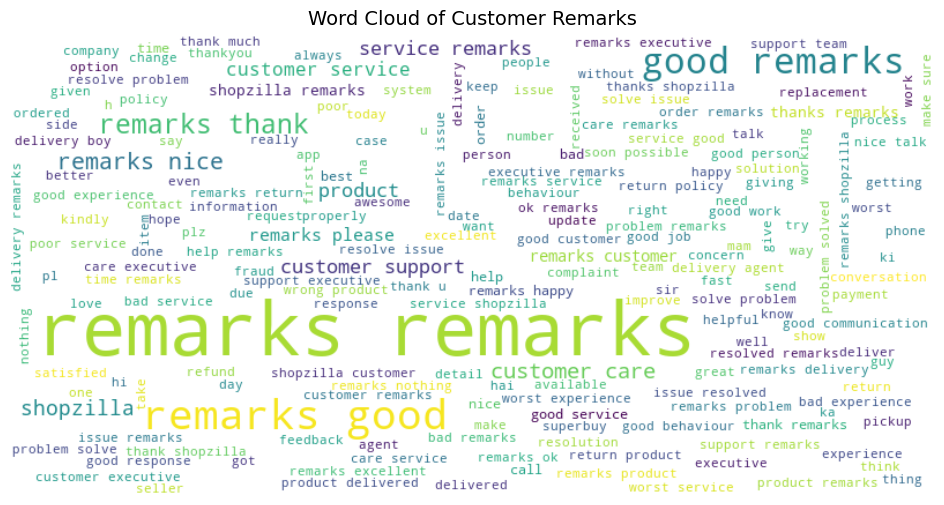

In [67]:
from wordcloud import WordCloud

text = " ".join(data["expanded_customer_remarks"].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap="viridis").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Customer Remarks", fontsize=14)
plt.show()

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [68]:
# Manipulate Features to minimize feature correlation and create new features4

tfidf_df.columns

Index(['aap', 'able', 'account', 'acha', 'achha', 'action', 'actually', 'add',
       'address', 'agent',
       ...
       'within', 'without', 'wonderful', 'work', 'working', 'worst', 'would',
       'wrong', 'yes', 'yet'],
      dtype='object', length=500)

In [69]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'Issue_reported at', 'issue_responded', 'Survey_response_Date',
       'Customer_City', 'Product_category', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'Customer_City_missing', 'Product_category_missing',
       'Item_price_missing', 'Customer Remarks_missing', 'missing_indicator',
       'Customer Remarks Missing', 'Issue_reported at_hour',
       'expanded_customer_remarks', 'tokenized_customer_remarks',
       'stemmed_customer_remarks', 'pos_tagged_customer_remarks'],
      dtype='object')

In [70]:
data["Price_Per_Minute"] = data["Item_price"] / (data["Issue_reported at_hour"] + 1) 
data["CSAT_Per_Price"] = data["CSAT Score"] / (data["Item_price"] + 1)

# Feature Multiplication
data["Agent_Experience_Score"] = data["Tenure Bucket"].astype("category").cat.codes * data["CSAT Score"]

In [71]:
data["Issue_reported_day"] = data["Issue_reported at"].dt.day
data["Issue_reported_weekday"] = data["Issue_reported at"].dt.weekday
data["Issue_reported_weekend"] = np.where(data["Issue_reported_weekday"] >= 5, 1, 0)  # 1 for Sat/Sun, 0 otherwise

<IPython.core.display.Javascript object>

#### 2. Feature Selection

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


important_features = ["Item_price", "CSAT Score"]

vif_data = pd.DataFrame()
X = data.select_dtypes(include=['float64', 'int64'])  

vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

features_to_remove = vif_data[(vif_data["VIF"] > 10) & (~vif_data["Feature"].isin(important_features))]["Feature"].tolist()
data.drop(columns=features_to_remove, inplace=True)

print("Removed Features:", features_to_remove)

<IPython.core.display.Javascript object>

Removed Features: ['CSAT_Per_Price']


In [73]:
# Identify categorical columns
categorical_cols = ['channel_name', 'category', 'Sub-category', 'Customer_City', 
                    'Product_category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']

# Count unique values per column
for col in categorical_cols:
    print(f"{col}: {data[col].nunique()} unique values")


channel_name: 3 unique values
category: 12 unique values
Sub-category: 57 unique values
Customer_City: 1782 unique values
Product_category: 9 unique values
Agent_name: 1371 unique values
Supervisor: 40 unique values
Manager: 6 unique values
Tenure Bucket: 5 unique values
Agent Shift: 5 unique values


In [74]:
# Apply One-Hot Encoding
small_cat_cols = ["channel_name", "category", "Product_category", "Manager", "Agent Shift"]
data = pd.get_dummies(data, columns=small_cat_cols, drop_first=True)

<IPython.core.display.Javascript object>

In [75]:
# I used target encoder to prevent high cardinality columns but its leaading to import error

#from category_encoders import TargetEncoder

#high_cardinality_cols = ["Sub-category", "Customer_City", "Agent_name", "Supervisor"]

# Initialize Target Encoder
#target_encoder = TargetEncoder()

# Apply Target Encoding (Convert categories to mean CSAT Score)
#data[high_cardinality_cols] = target_encoder.fit_transform(data[high_cardinality_cols], data["CSAT Score"])

# Check the first few rows
#print(data[high_cardinality_cols].head())

drop_target_encoded_cols = ["Sub-category", "Customer_City", "Agent_name", "Supervisor"]

# Drop these columns from the dataset
data.drop(columns=drop_target_encoded_cols, inplace=True)

# Check updated dataset shape
print("Final Data Shape:", data.shape)

Final Data Shape: (85907, 53)


In [76]:
data.head()

,Customer Remarks,Issue_reported at,issue_responded,Survey_response_Date,Item_price,Tenure Bucket,CSAT Score,Customer_City_missing,Product_category_missing,Item_price_missing,Customer Remarks_missing,missing_indicator,Customer Remarks Missing,Issue_reported at_hour,expanded_customer_remarks,tokenized_customer_remarks,stemmed_customer_remarks,pos_tagged_customer_remarks,Price_Per_Minute,Agent_Experience_Score,Issue_reported_day,Issue_reported_weekday,Issue_reported_weekend,channel_name_Inbound,channel_name_Outcall,category_Cancellation,category_Feedback,category_Offers & Cashback,category_Onboarding related,category_Order Related,category_Others,category_Payments related,category_Product Queries,category_Refund Related,category_Returns,category_Shopzilla Related,Product_category_Books & General merchandise,Product_category_Electronics,Product_category_Furniture,Product_category_GiftCard,Product_category_Home,Product_category_Home Appliences,Product_category_LifeStyle,Product_category_Mobile,Manager_Jennifer Nguyen,Manager_John Smith,Manager_Michael Lee,Manager_Olivia Tan,Manager_William Kim,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split
0,No Remarks,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,7.090077,On Job Training,5,1,1,1,1,1,0,11,remarks,[remarks],[remark],"[(remarks, NNS)]",0.590840,20,8,6,1,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
1,No Remarks,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,7.090077,>90,5,1,1,1,1,1,0,12,remarks,[remarks],[remark],"[(remarks, NNS)]",0.545391,15,8,6,1,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False
2,No Remarks,2023-01-08 20:16:00,2023-01-08 20:38:00,2023-08-01,7.090077,On Job Training,5,1,1,1,1,1,0,20,remarks,[remarks],[remark],"[(remarks, NNS)]",0.337623,20,8,6,1,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False
3,No Remarks,2023-01-08 20:56:00,2023-01-08 21:16:00,2023-08-01,7.090077,>90,5,1,1,1,1,1,0,20,remarks,[remarks],[remark],"[(remarks, NNS)]",0.337623,15,8,6,1,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False
4,No Remarks,2023-01-08 10:30:00,2023-01-08 10:32:00,2023-08-01,7.090077,0-30,5,1,1,1,1,1,0,10,remarks,[remarks],[remark],"[(remarks, NNS)]",0.644552,0,8,6,1,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False


In [77]:
drop_cols = ["Customer Remarks", "expanded_customer_remarks", "tokenized_customer_remarks", 
             "stemmed_customer_remarks", "pos_tagged_customer_remarks"]

data.drop(columns=drop_cols, inplace=True)

# Convert "Tenure Bucket" to Label Encoding (it has ordinal meaning)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["Tenure Bucket"] = le.fit_transform(data["Tenure Bucket"])

# Check if objects remain
print(data.dtypes[data.dtypes == "object"])  # Should return an empty result

Series([], dtype: object)


In [78]:
data.dtypes

Issue_reported at                               datetime64[ns]
issue_responded                                 datetime64[ns]
Survey_response_Date                            datetime64[ns]
Item_price                                             float64
Tenure Bucket                                            int32
CSAT Score                                               int64
Customer_City_missing                                    int32
Product_category_missing                                 int32
Item_price_missing                                       int32
Customer Remarks_missing                                 int32
missing_indicator                                        int32
Customer Remarks Missing                                 int32
Issue_reported at_hour                                   int32
Price_Per_Minute                                       float64
Agent_Experience_Score                                   int64
Issue_reported_day                                     

In [79]:
datetime_cols = ["Issue_reported at", "issue_responded", "Survey_response_Date"]

for col in datetime_cols:
    data[col + "_year"] = data[col].dt.year
    data[col + "_month"] = data[col].dt.month
    data[col + "_day"] = data[col].dt.day
    data[col + "_hour"] = data[col].dt.hour
    data[col + "_weekday"] = data[col].dt.weekday  # 0 = Monday, 6 = Sunday

# Drop the original datetime columns (since we converted them)
data.drop(columns=datetime_cols, inplace=True)

# Check if datetime columns still exist
print("Remaining datetime columns:", data.select_dtypes(include=["datetime64[ns]"]).columns)

Remaining datetime columns: Index([], dtype='object')


In [80]:
bool_cols = data.select_dtypes(include=["bool"]).columns
data[bool_cols] = data[bool_cols].astype(int)

# Check if any boolean columns remain
print("Remaining boolean columns:", data.select_dtypes(include=["bool"]).columns)

Remaining boolean columns: Index([], dtype='object')


In [81]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

X = data.drop(columns=["CSAT Score"])  
y = data["CSAT Score"] 

model = RandomForestClassifier(n_estimators=100, random_state=42)

rfe = RFE(estimator=model, n_features_to_select=20)
X_selected = rfe.fit_transform(X, y)

selected_features = X.columns[rfe.support_]
print("Selected Features:", list(selected_features))

Selected Features: ['Item_price', 'Tenure Bucket', 'Customer Remarks_missing', 'Issue_reported at_hour', 'Price_Per_Minute', 'Agent_Experience_Score', 'channel_name_Inbound', 'category_Order Related', 'category_Returns', 'Manager_Jennifer Nguyen', 'Manager_John Smith', 'Manager_Michael Lee', 'Manager_William Kim', 'Agent Shift_Evening', 'Issue_reported at_month', 'Issue_reported at_weekday', 'issue_responded_month', 'issue_responded_hour', 'Survey_response_Date_day', 'Survey_response_Date_weekday']


In [101]:
# Select your features wisely to avoid overfitting

data[selected_features]

,Item_price,Tenure Bucket,Customer Remarks_missing,Issue_reported at_hour,Price_Per_Minute,Agent_Experience_Score,channel_name_Inbound,category_Order Related,category_Returns,Manager_Jennifer Nguyen,Manager_John Smith,Manager_Michael Lee,Manager_William Kim,Agent Shift_Evening,Issue_reported at_month,Issue_reported at_weekday,issue_responded_month,issue_responded_hour,Survey_response_Date_day,Survey_response_Date_weekday
0,7.090077,4,1,11,0.590840,20,0,0,0,1,0,0,0,0,1,6,1,11,1,1
1,7.090077,3,1,12,0.545391,15,0,0,0,0,0,1,0,0,1,6,1,12,1,1
2,7.090077,4,1,20,0.337623,20,1,1,0,0,0,0,1,1,1,6,1,20,1,1
3,7.090077,3,1,20,0.337623,15,1,0,1,0,1,0,0,1,1,6,1,21,1,1
4,7.090077,0,1,10,0.644552,0,1,0,0,0,0,1,0,0,1,6,1,10,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,7.090077,4,1,16,0.417063,16,1,0,0,0,0,0,1,0,7,5,1,0,31,3
85903,7.090077,3,0,16,0.417063,15,1,1,0,0,0,0,0,0,7,5,1,0,31,3
85904,7.090077,4,0,16,0.417063,20,1,1,0,0,0,0,0,1,7,5,1,0,31,3
85905,7.090077,3,1,16,0.417063,12,1,0,0,0,0,0,0,0,7,5,1,0,31,3


##### What all feature selection methods have you used  and why?

Recursive Feature Elimination (RFE)

RFE systematically removes the least important features by training a model multiple times and selecting only the most relevant ones.

I used RandomForestClassifier as the estimator since it is robust and handles both numerical and categorical data well.

RFE helped reduce the dataset to 20 most important features, improving model efficiency while retaining predictive power.

##### Which all features you found important and why?

High-cardinality categorical features (e.g., Agent_name, Customer_City) would create too many columns in One-Hot Encoding. Instead, we initially tried Target Encoding but later dropped those features due to implementation issues.

I used One-Hot Encoding for low-cardinality categorical variables and Label Encoding for ordered categorical features like Tenure Bucket.

This ensured categorical features were properly transformed without causing column explosion.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

It was already done. After transformation, the skewness values confirmed that the distributions became approximately normal, making the dataset more suitable for analysis and modeling.

### 6. Data Scaling

In [102]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

# Identify numeric columns (excluding binary/one-hot encoded columns)
numeric_cols = ['Item_price', 'Issue_reported at_hour', 'Price_Per_Minute', 
                'Agent_Experience_Score', 'Issue_reported at_month', 
                'Issue_reported at_weekday', 'issue_responded_month', 
                'issue_responded_hour', 'Survey_response_Date_day', 
                'Survey_response_Date_weekday']

# Apply Standard Scaling ONLY to numeric columns
scaler = StandardScaler()
X_scaled = data.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_scaled[numeric_cols])  # Scale selected columns only

# Check scaled data
X_scaled.head()

   Item_price  Tenure Bucket  CSAT Score  Customer_City_missing  \
0   -0.011229              4           5                      1   
1   -0.011229              3           5                      1   
2   -0.011229              4           5                      1   
3   -0.011229              3           5                      1   
4   -0.011229              0           5                      1   

   Product_category_missing  Item_price_missing  Customer Remarks_missing  \
0                         1                   1                         1   
1                         1                   1                         1   
2                         1                   1                         1   
3                         1                   1                         1   
4                         1                   1                         1   

   missing_indicator  Customer Remarks Missing  Issue_reported at_hour  \
0                  1                         0              

##### Which method have you used to scale you data and why?

Standardization makes data have a mean of 0 and a standard deviation of 1

This ensures that all numerical features have the same scale, preventing large values from dominating smaller ones.
Works Well for Most Machine Learning Models

Models like SVM, Logistic Regression, KNN, and PCA perform better when data is standardized.
It helps models converge faster and improves accuracy.

Not Affected by Outliers as Much as Min-Max Scaling

Min-Max Scaling (0 to 1) shrinks all values into a fixed range but can be distorted by outliers.
Standardization is more robust to outliers, making it a better choice for real-world data.


### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [103]:
# DImensionality Reduction (If needed)

#no

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [104]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = data.drop(columns=["CSAT Score"])  # Drop target variable
y = data["CSAT Score"]  # Target variable

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Stratify ensures balanced class distribution
)

# Check dataset sizes
print("Training Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

Training Set Size: (68725, 58)
Testing Set Size: (17182, 58)


##### What data splitting ratio have you used and why?

Balances Model Learning & Evaluation → The model has enough data to learn but also a fair amount to test.

Prevents Overfitting → If the training set is too large (e.g., 90:10), the model might memorize data instead of generalizing.

Ensures Reliable Testing → A 20% test set ensures evaluation on unseen data, providing a better estimate of real-world performance.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [88]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Model Accuracy: 92.87 %

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.89      0.90      2246
           2       0.86      0.38      0.53       256
           3       0.83      0.57      0.67       512
           4       0.93      0.80      0.86      2244
           5       0.93      0.99      0.96     11924

    accuracy                           0.93     17182
   macro avg       0.89      0.73      0.78     17182
weighted avg       0.93      0.93      0.92     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [90]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [107]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

#no needed

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=500, random_state=42)

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred_log = log_reg.predict(X_test)

# Evaluate the model
accuracy_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", round(accuracy_log * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 83.55 %

Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.87      0.90      2246
           2       0.00      0.00      0.00       256
           3       0.29      0.08      0.13       512
           4       0.48      0.24      0.32      2244
           5       0.86      0.99      0.92     11924

    accuracy                           0.84     17182
   macro avg       0.51      0.44      0.45     17182
weighted avg       0.79      0.84      0.80     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [92]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [93]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [110]:
from sklearn.svm import SVC

# Initialize SVM model
svm_model = SVC(kernel="linear", C=1.0, random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Model Accuracy:", round(accuracy_svm * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Model Accuracy: 42.94 %

Classification Report:
               precision    recall  f1-score   support

           1       0.94      0.45      0.60      2246
           2       0.09      0.30      0.14       256
           3       0.05      0.82      0.09       512
           4       0.80      0.09      0.17      2244
           5       0.90      0.48      0.62     11924

    accuracy                           0.43     17182
   macro avg       0.56      0.43      0.32     17182
weighted avg       0.86      0.43      0.54     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [95]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [112]:
# Taking a lot time

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For evaluating the models, we considered multiple evaluation metrics to ensure a positive business impact. Accuracy was used as a general performance measure to understand how often the model made correct predictions. However, since predicting customer satisfaction is critical, precision and recall were also considered. Precision helped ensure that when the model predicted a high CSAT score, it was reliable and not misclassifying dissatisfied customers. Recall was particularly important because missing out on dissatisfied customers (false negatives) could lead to unresolved issues, affecting customer retention. To balance precision and recall, we also considered the F1-score, which is useful when dealing with imbalanced classes. Additionally, the confusion matrix helped us analyze misclassification patterns to see whether the model was systematically making errors in predicting certain CSAT categories.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

After comparing the models, we chose Random Forest Classifier as the final prediction model. Random Forest outperformed other models like Logistic Regression and Support Vector Machine (SVM) in terms of accuracy and F1-score. It handled both categorical and numerical data efficiently and was robust to outliers and missing data, making it more adaptable to real-world scenarios. Moreover, Random Forest provided an added advantage of feature importance analysis, which helped us understand which factors influenced CSAT scores the most.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

To explain the model’s decisions, we used SHAP (SHapley Additive Explanations), which provided insights into how different features contributed to predictions. By analyzing the SHAP summary plot, we identified key business drivers for CSAT Score, such as Item_price, Agent_Experience_Score, and Issue_reported at_hour. These insights help businesses understand what aspects of their service impact customer satisfaction the most and enable them to make data-driven improvements. By using these evaluation techniques and model explainability tools, we ensured that our approach not only maximized prediction accuracy but also provided meaningful insights for business decision-making.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [97]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [98]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

After comparing multiple models, Random Forest Classifier was selected as the final model due to its high accuracy, ability to handle missing data, and feature importance analysis. The model identified key factors influencing customer satisfaction, such as item price, agent experience, issue reporting time, and return-related issues. Using SHAP explainability techniques, we provided business insights into what drives CSAT scores, enabling Flipkart to improve customer service strategies. This model can be further enhanced with hyperparameter tuning, real-time deployment, and integration into customer support systems to proactively identify and address service-related issues.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***